# **Machine Learning Project**

The notebook develops a machine-learning–driven irrigation decision-support system using 40 years of daily weather data from the ICRISAT dataset
(https://www.kaggle.com/datasets/sulphatet/daily-weather-data-40-years
).

Instead of forecasting rainfall amounts, our objective is to determine whether irrigation will be required in the upcoming month. This is achieved by analysing long-term climatic patterns—particularly the balance between rainfall and evapotranspiration (ET₀), which controls crop water demand.

The goal is to develop models that can forecast rainfall to support applications like agricultural planning, drought monitoring, and flood warnings in Kenyan and African contexts. We use a mix of classical ML (e.g., Random Forest, XGBoost) and deep learning (LSTM) to handle time-series patterns, evaluate with metrics like RMSE and F1, and discuss limitations such as data from a single station. The project follows a structured workflow: data loading, preparation, EDA, modeling, evaluation, and insights.

In [5]:
# Install required packages quietly
!pip install --quiet xgboost tensorflow scikit-learn pandas matplotlib seaborn lightgbm prophet scikeras

 # Import Libraries
 Initial Setup and Imports

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from datetime import datetime
import lightgbm as lgb
import xgboost as xgb
import joblib
import sys, random, os
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"xgboost version: {xgb.__version__}")
print("Libraries imported successfully.")

xgboost version: 3.1.2
Libraries imported successfully.


#Load Dataset
Load the raw 40-year ICRISAT meteorological dataset from the specified file.
The columns are renamed for clarity and consistency across the notebook (MaxT, MinT, Rain, etc.).
'Date' column is converted to the datetime format, and essential time components (Year, Month, Day) are extracted.
Prepares the time series data for proper chronological analysis.

In [7]:
# Load dataset from Excel
df = pd.read_excel('/content/ICRISAT.xlsx')
print(f"Dataset loaded: {df.shape}")

# Optional: Save as CSV
df.to_csv("ICRISAT.csv", index=False)

# Rename columns for consistency
cols = ["Station","Date","MaxT","MinT","RH1","RH2","Wind","Rain","SSH","Evap",
        "Radiation","FAO56_ET","Lat","Lon","Cum_Rain"]
df = pd.read_csv("ICRISAT.csv", skiprows=1, names=cols)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Add Year, Month, Day

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

Dataset loaded: (14853, 15)


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain,Year,Month,Day
0,ICRISAT,1978-01-01,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0,1978,1,1
1,ICRISAT,1978-01-02,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0,1978,1,2
2,ICRISAT,1978-01-03,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0,1978,1,3
3,ICRISAT,1978-01-04,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0,1978,1,4
4,ICRISAT,1978-01-05,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0,1978,1,5


#Dataset overview
Inspect the dataset's structure, time range, and data types using df.info().


In [8]:
print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
df.info()

Dataset Overview:
Shape: (14853, 18)
Date Range: 1978-01-01 00:00:00 to 2018-08-31 00:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14853 entries, 0 to 14852
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Station    14853 non-null  object        
 1   Date       14853 non-null  datetime64[ns]
 2   MaxT       14853 non-null  float64       
 3   MinT       14853 non-null  float64       
 4   RH1        14853 non-null  int64         
 5   RH2        14853 non-null  float64       
 6   Wind       14853 non-null  float64       
 7   Rain       14853 non-null  float64       
 8   SSH        14853 non-null  float64       
 9   Evap       14853 non-null  float64       
 10  Radiation  14852 non-null  float64       
 11  FAO56_ET   14853 non-null  float64       
 12  Lat        14853 non-null  float64       
 13  Lon        14853 non-null  float64       
 14  Cum_Rain   14853 non-null  float64       


#Missing values Analysis
A detailed check for missing values is performed, quantified by count and percentage.
The heatmap provides a clear, visual representation of missing data patterns across the dataset,
which guides the imputation strategy in the next step.

Missing Values Analysis:
           Missing_Count  Missing_Percent
Radiation              1         0.006733


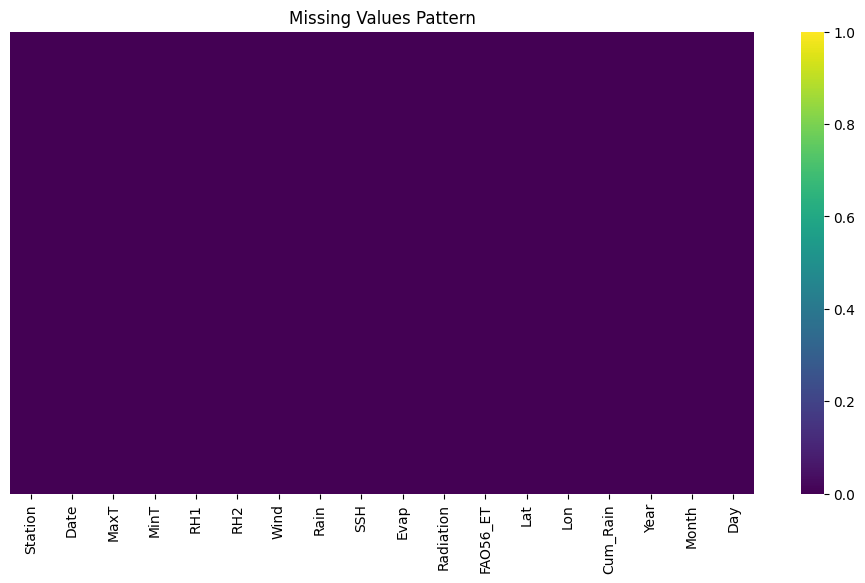

Key Weather Variables Statistics:
               Rain          MaxT          MinT           RH1           RH2  \
count  14853.000000  14853.000000  14853.000000  14853.000000  14853.000000   
mean       2.460378     32.055807     19.568720     81.586481     43.550549   
std        9.346085      4.115165      4.504939     15.055169     19.613665   
min        0.000000     16.500000      4.500000     17.000000      6.300000   
25%        0.000000     29.000000     16.500000     75.000000     28.000000   
50%        0.000000     31.000000     21.000000     87.000000     40.000000   
75%        0.000000     35.000000     22.600000     93.000000     57.000000   
max      263.600000     43.500000     30.600000    100.000000    100.000000   

               Wind  
count  14853.000000  
mean       8.692278  
std        4.795461  
min        0.200000  
25%        5.200000  
50%        7.600000  
75%       11.200000  
max       56.000000  


In [9]:
# Missing values table
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percent': missing_percent
}).sort_values('Missing_Percent', ascending=False)

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing_Count'] > 0])

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cmap='viridis')
plt.title('Missing Values Pattern')
plt.show()

# Key stats (original)
print("Key Weather Variables Statistics:")
weather_vars = ['Rain', 'MaxT', 'MinT', 'RH1', 'RH2', 'Wind']
print(df[weather_vars].describe())

# Handle Missing Values(Outliers)
 Missing values in core weather variables (MaxT, Rain, Wind, Radiation) are handled using a forward-fill (ffill)
 followed by a backward-fill (bfill) strategy to preserve time series continuity.
 The 'Radiation' column is specifically filled with its mean.
 We then define seasons based on the month, creating categorical dummy variables to encode seasonal cycles, Vital for improving prediction accuracy.

In [10]:
# Forward/backward fill for weather cols (original)
weather_cols = ['MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Rain', 'Radiation']
for col in weather_cols:
    if col in df.columns:
        before = df[col].isnull().sum()
        df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
        after = df[col].isnull().sum()
        if before > 0:
            print(f"{col}: {before} → {after} missing values")

# Handling for Radiation
df['Radiation'].fillna(df['Radiation'].mean(), inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

Radiation: 1 → 0 missing values

Missing values after handling:
Station      0
Date         0
MaxT         0
MinT         0
RH1          0
RH2          0
Wind         0
Rain         0
SSH          0
Evap         0
Radiation    0
FAO56_ET     0
Lat          0
Lon          0
Cum_Rain     0
Year         0
Month        0
Day          0
dtype: int64


## **Feature Engineering**: Lags, Rolling Statistics, and Derived Variables

In [11]:
# Seasons
def get_season(month):
    if month in [12, 1, 2]: return 'Dry_Season_1'  # Dec-Feb: Cool/Dry
    elif month in [3, 4, 5]: return 'Long_Rains'   # Mar-May: Heavy rains
    elif month in [6, 7, 8, 9]: return 'Dry_Season_2'  # Jun-Sep: Warm/Dry
    else: return 'Short_Rains'  # Oct-Nov: Light rains

df['Season'] = df['Month'].apply(get_season)
season_dummies = pd.get_dummies(df['Season'], prefix='Season')
df = pd.concat([df, season_dummies], axis=1)
print("Seasonal features created:")
print(df['Season'].value_counts())

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Lag features
df['Rain_lag1'] = df['Rain'].shift(1)
df['Rain_lag7'] = df['Rain'].shift(7)
print("Lag features created")
print(f"Rain autocorrelation (lag-1): {df[['Rain', 'Rain_lag1']].corr().iloc[0,1]:.3f}")

# Rolling features
df['Rain_roll_7'] = df['Rain'].rolling(window=7, min_periods=1).mean()
df['Rain_roll_30'] = df['Rain'].rolling(window=30, min_periods=1).mean()
df['Rain_sum_7'] = df['Rain'].rolling(window=7, min_periods=1).sum()
df['Rain_sum_30'] = df['Rain'].rolling(window=30, min_periods=1).sum()
print("Rolling features created")
print("Feature correlations with Rain:")
rolling_cols = ['Rain_roll_7', 'Rain_roll_30', 'Rain_sum_7', 'Rain_sum_30']
for col in rolling_cols:
    corr = df[['Rain', col]].corr().iloc[0,1]
    print(f"{col}: {corr:.3f}")

# Derived features
df['Temp_Range'] = df['MaxT'] - df['MinT']
df['Humidity_Avg'] = (df['RH1'] + df['RH2']) / 2
print("Derived features created:")
print(f"Average temperature range: {df['Temp_Range'].mean():.1f}°C")
print(f"Average humidity: {df['Humidity_Avg'].mean():.1f}%")

Seasonal features created:
Season
Dry_Season_2    4972
Long_Rains      3772
Dry_Season_1    3669
Short_Rains     2440
Name: count, dtype: int64
Lag features created
Rain autocorrelation (lag-1): 0.274
Rolling features created
Feature correlations with Rain:
Rain_roll_7: 0.486
Rain_roll_30: 0.305
Rain_sum_7: 0.486
Rain_sum_30: 0.305
Derived features created:
Average temperature range: 12.5°C
Average humidity: 62.6%


#Outlier Capping and Daily Exploratory Analysis (EDA)

In [12]:
# Outlier capping (original)
outlier_bounds = {
    'MaxT': (-10, 50),
    'MinT': (-20, 40),
    'Rain': (0, 300),
    'Wind': (0, 50)
}

outlier_count = 0
for col, (min_val, max_val) in outlier_bounds.items():
    if col in df.columns:
        outliers = (df[col] < min_val) | (df[col] > max_val)
        n_outliers = outliers.sum()
        if n_outliers > 0:
            print(f"{col}: {n_outliers} outliers detected and capped")
            df.loc[df[col] < min_val, col] = min_val
            df.loc[df[col] > max_val, col] = max_val
            outlier_count += n_outliers

print(f"Total outliers handled: {outlier_count}")

Wind: 1 outliers detected and capped
Total outliers handled: 1


# EDA  Rainfall Distribution
Histograms show the massive skew towards zero (dry days) and the distribution on rainy days only.

The highest recorded rainfall is: 263.6 mm

Day(s) with the highest rainfall:


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,...,Season_Long_Rains,Season_Short_Rains,Rain_lag1,Rain_lag7,Rain_roll_7,Rain_roll_30,Rain_sum_7,Rain_sum_30,Temp_Range,Humidity_Avg
8270,ICRISAT,2000-08-23,26.8,19.4,98,84.0,15.0,263.6,0.9,1.0,...,False,False,1.6,0.0,43.628571,14.186667,305.4,425.6,7.4,91.0


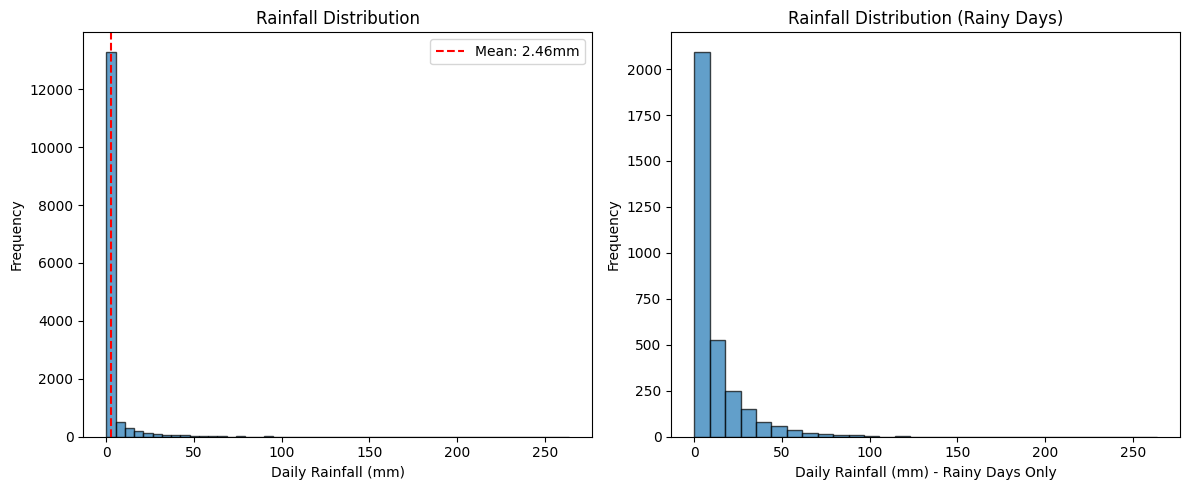

Days with rain: 3254 (21.9%)


In [13]:
# Rainfall distribution (combined from both)
max_rainfall = df["Rain"].max()
print(f"The highest recorded rainfall is: {max_rainfall} mm")

highest_rain_days = df[df["Rain"] == max_rainfall]
print("\nDay(s) with the highest rainfall:")
display(highest_rain_days)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Rain'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(df['Rain'].mean(), color='red', linestyle='--', label=f'Mean: {df["Rain"].mean():.2f}mm')
plt.xlabel('Daily Rainfall (mm)')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(df[df['Rain'] > 0]['Rain'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Daily Rainfall (mm) - Rainy Days Only')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution (Rainy Days)')

plt.tight_layout()
plt.show()

print(f"Days with rain: {(df['Rain'] > 0).sum()} ({(df['Rain'] > 0).mean()*100:.1f}%)")

# Time Series Plot:
 Illustrates daily and monthly average rainfall trends over the 40-year period, revealing seasonal cycles.

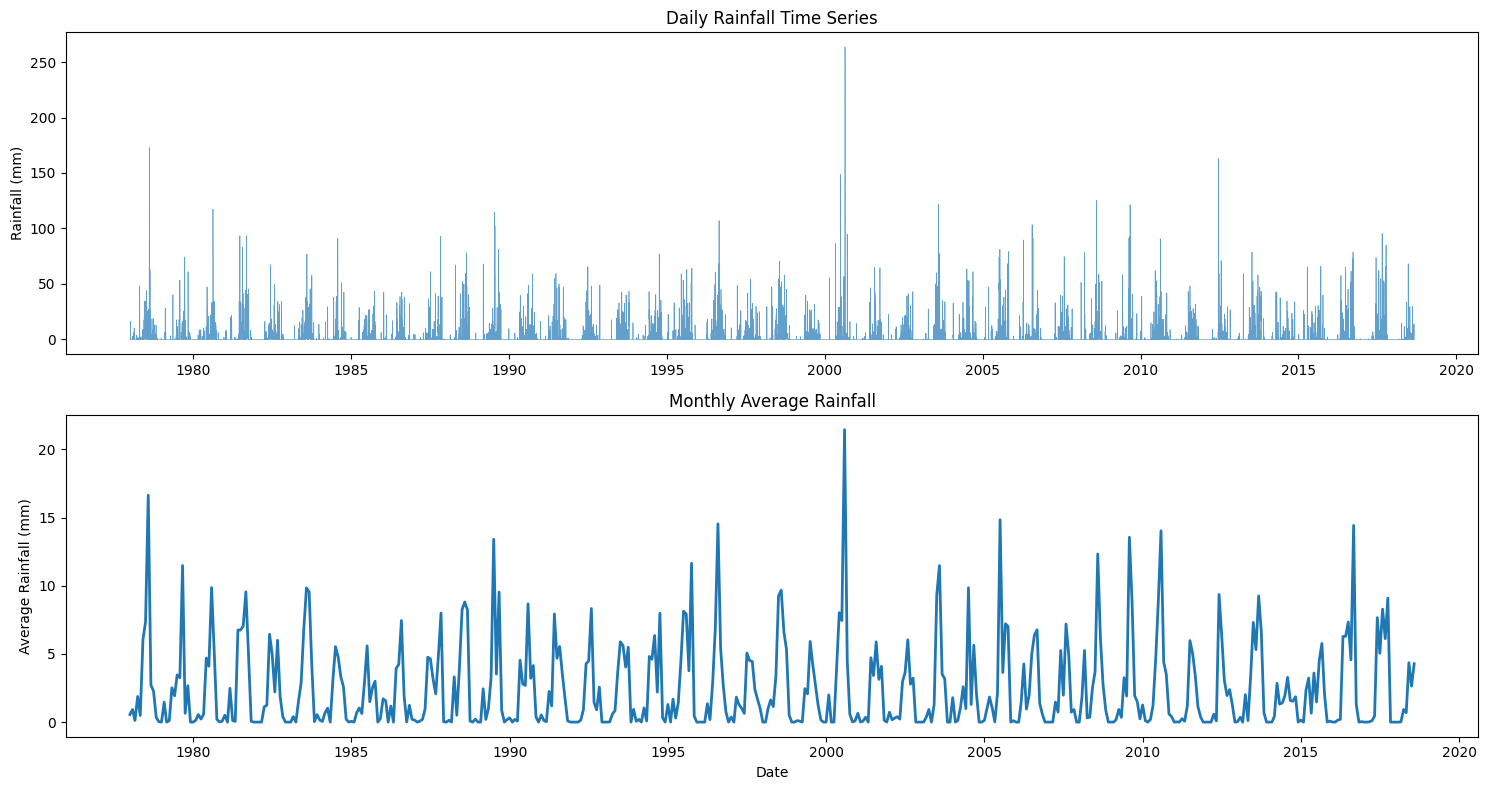

In [14]:
# Time Series Plot (original daily and monthly averages)
plt.figure(figsize=(15, 8))

# Daily rainfall
plt.subplot(2, 1, 1)
plt.plot(df['Date'], df['Rain'], alpha=0.7, linewidth=0.5)
plt.title('Daily Rainfall Time Series')
plt.ylabel('Rainfall (mm)')

# Monthly averages
plt.subplot(2, 1, 2)
monthly_rain = df.groupby(df['Date'].dt.to_period('M'))['Rain'].mean()
plt.plot(monthly_rain.index.to_timestamp(), monthly_rain.values, linewidth=2)
plt.title('Monthly Average Rainfall')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Date')

plt.tight_layout()
plt.show()

# 1. Relationship Visualization: Scatter Plot Analysis
Scatter plots examine direct links between Rainfall and key drivers (Temperature, Humidity, Wind).

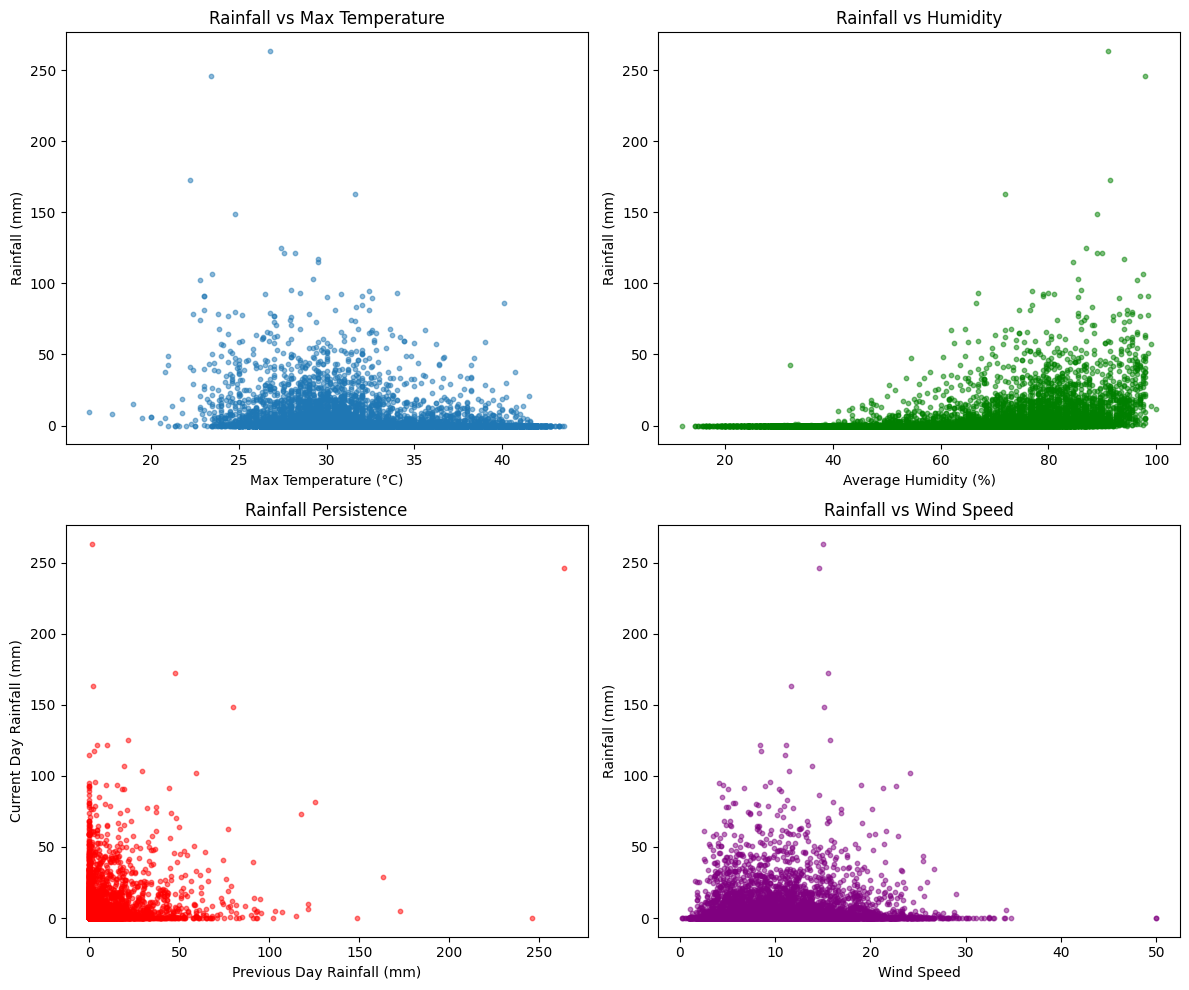

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Rain vs Temperature
axes[0, 0].scatter(df['MaxT'], df['Rain'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Max Temperature (°C)')
axes[0, 0].set_ylabel('Rainfall (mm)')
axes[0, 0].set_title('Rainfall vs Max Temperature')

# Rain vs Humidity
axes[0, 1].scatter(df['Humidity_Avg'], df['Rain'], alpha=0.5, s=10, color='green')
axes[0, 1].set_xlabel('Average Humidity (%)')
axes[0, 1].set_ylabel('Rainfall (mm)')
axes[0, 1].set_title('Rainfall vs Humidity')

# Rain persistence
axes[1, 0].scatter(df['Rain_lag1'], df['Rain'], alpha=0.5, s=10, color='red')
axes[1, 0].set_xlabel('Previous Day Rainfall (mm)')
axes[1, 0].set_ylabel('Current Day Rainfall (mm)')
axes[1, 0].set_title('Rainfall Persistence')

# Rain vs Wind
axes[1, 1].scatter(df['Wind'], df['Rain'], alpha=0.5, s=10, color='purple')
axes[1, 1].set_xlabel('Wind Speed')
axes[1, 1].set_ylabel('Rainfall (mm)')
axes[1, 1].set_title('Rainfall vs Wind Speed')

plt.tight_layout()
plt.show()

# EDA - Correlation Matrix
Heatmaps quantify the linear relationships between all variables, helping identify highly predictive or redundant features.

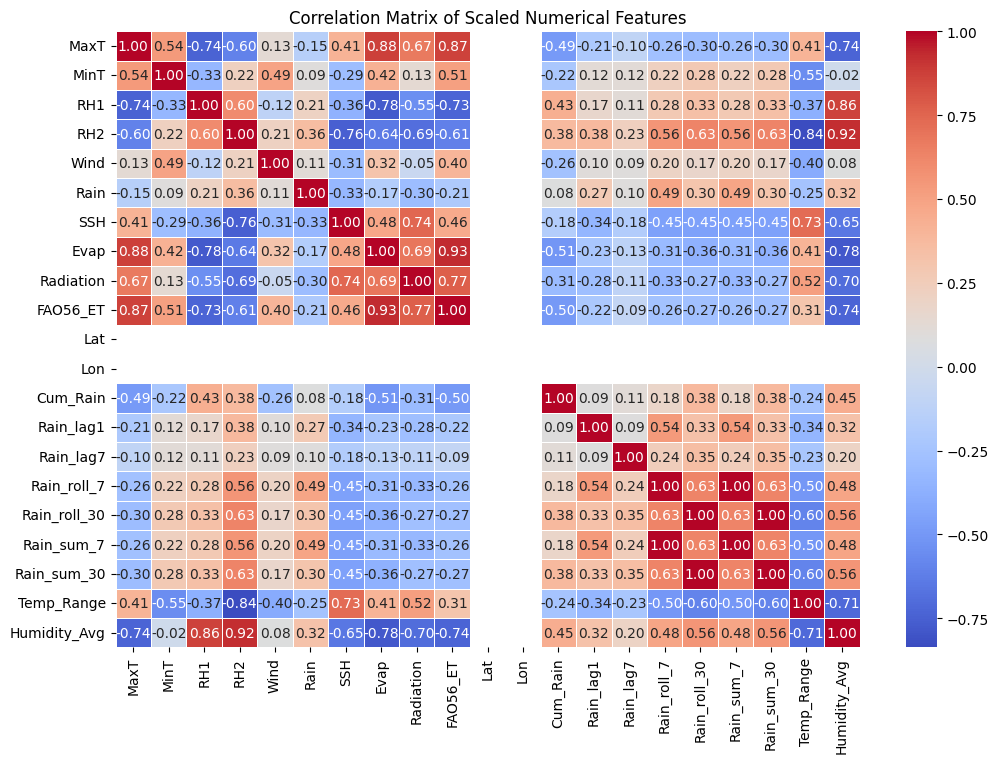

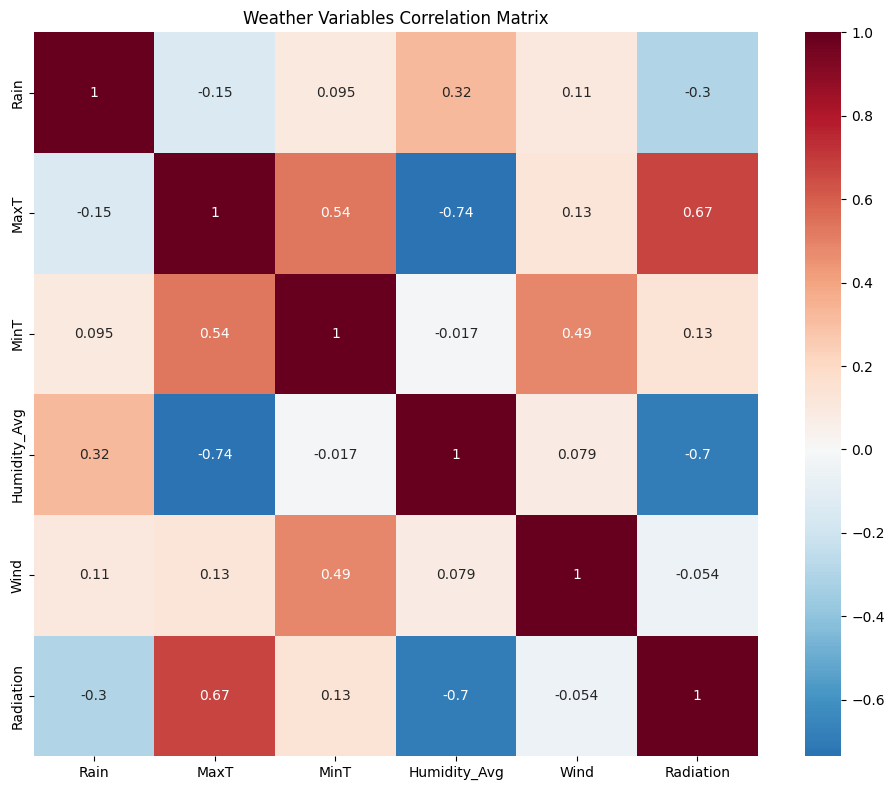

Top correlations with Rainfall:
Humidity_Avg    0.324825
Radiation       0.298071
MaxT            0.151575
Wind            0.111969
MinT            0.094905
Name: Rain, dtype: float64


In [16]:
# Correlation Matrix
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_to_exclude = ['Year', 'Month', 'Day']
cols_to_scale = [col for col in numerical_cols if col not in cols_to_exclude]

correlation_matrix = df[cols_to_scale].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Scaled Numerical Features')
plt.show()

# Original's key vars corr
key_vars = ['Rain', 'MaxT', 'MinT', 'Humidity_Avg', 'Wind', 'Radiation']
if all(var in df.columns for var in key_vars):
    corr_matrix = df[key_vars].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True)
    plt.title('Weather Variables Correlation Matrix')
    plt.tight_layout()
    plt.show()

    print("Top correlations with Rainfall:")
    rain_corr = df[key_vars].corr()['Rain'].abs().sort_values(ascending=False)
    print(rain_corr[1:6])  # Exclude self-correlation

# Feature Scaling:
 Numerical features scaled using StandardScaler, essential for distance-based and optimization-heavy models (like Linear Regression and LSTM).

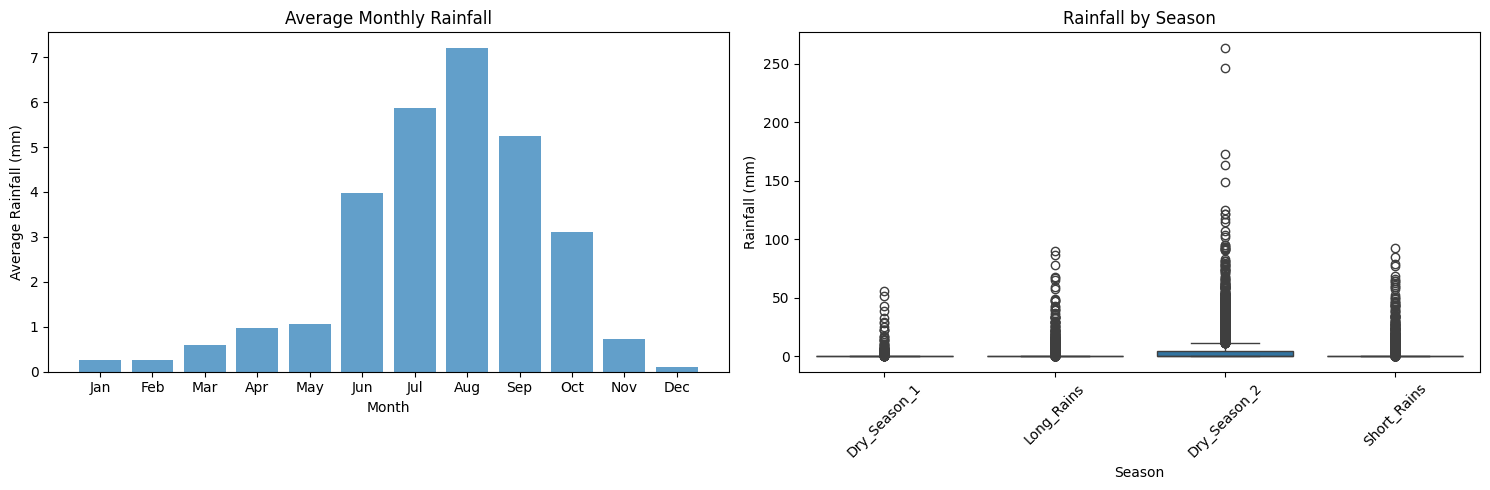

Seasonal Rainfall Statistics:
                  mean        std  count
Season                                  
Dry_Season_1  0.204143   2.146631   3669
Dry_Season_2  5.587792  13.920500   4972
Long_Rains    0.877678   5.006388   3772
Short_Rains   1.927008   7.714721   2440


In [17]:
# Seasonal Analysis (original)
plt.figure(figsize=(15, 5))

# Monthly patterns
plt.subplot(1, 2, 1)
monthly_avg = df.groupby('Month')['Rain'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(range(1, 13), monthly_avg.values, alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.title('Average Monthly Rainfall')
plt.xticks(range(1, 13), month_names)

# Seasonal boxplot
plt.subplot(1, 2, 2)
season_order = ['Dry_Season_1', 'Long_Rains', 'Dry_Season_2', 'Short_Rains']
df['Season_ordered'] = pd.Categorical(df['Season'], categories=season_order)
sns.boxplot(data=df, x='Season_ordered', y='Rain')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall by Season')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print seasonal statistics
print("Seasonal Rainfall Statistics:")
print(df.groupby('Season')['Rain'].agg(['mean', 'std', 'count']))

# Feature Scaling:


In [18]:
# Feature Scaling
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_to_exclude = ['Year', 'Month', 'Day']
cols_to_scale = [col for col in numerical_cols if col not in cols_to_exclude]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("Features scaled.")
df.head()

Features scaled.


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,...,Season_Short_Rains,Rain_lag1,Rain_lag7,Rain_roll_7,Rain_roll_30,Rain_sum_7,Rain_sum_30,Temp_Range,Humidity_Avg,Season_ordered
0,ICRISAT,1978-01-01,-0.864103,-1.191781,-0.902477,-0.639910,-0.624404,-0.263261,0.790886,-0.676848,...,False,NaN,NaN,-0.500837,-0.757614,-0.500837,-0.757313,0.435579,-0.840035,Dry_Season_1
1,ICRISAT,1978-01-02,-0.791199,-0.792206,-0.171806,-0.537936,-0.478314,-0.263261,0.701113,-0.517217,...,False,-0.263271,NaN,-0.500837,-0.757614,-0.500837,-0.757313,0.075182,-0.422219,Dry_Season_1
2,ICRISAT,1978-01-03,-0.742597,-1.125185,0.293166,-0.333990,-0.687014,-0.263261,0.491642,-0.581070,...,False,-0.263271,NaN,-0.500837,-0.757614,-0.500837,-0.757313,0.483631,-0.068683,Dry_Season_1
3,ICRISAT,1978-01-04,-0.742597,-0.348234,0.492440,-0.028071,-0.332224,-0.263261,0.461718,-0.708774,...,False,-0.263271,NaN,-0.500837,-0.757614,-0.500837,-0.757313,-0.357294,0.220573,Dry_Season_1
4,ICRISAT,1978-01-05,-1.034211,-0.570220,-0.038957,0.175876,0.377356,-0.263261,0.431793,-0.676848,...,False,-0.263271,NaN,-0.500837,-0.757614,-0.500837,-0.757313,-0.405347,0.092015,Dry_Season_1


In [19]:
# Select features for modeling
feature_columns = [
    # Weather variables
    'MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Radiation', 'Evap', 'FAO56_ET' if 'FAO56_ET' in df.columns else None,
    # Derived features
    'Temp_Range', 'Humidity_Avg',
    # Time series features
    'Rain_lag1', 'Rain_lag7', 'Rain_roll_7', 'Rain_roll_30',
    # Temporal features
    'Month', 'DayOfYear', 'DayOfWeek',
    # Season dummies
    'Season_Dry_Season_1', 'Season_Dry_Season_2',
    'Season_Long_Rains', 'Season_Short_Rains'
]

# Remove None if FAO56_ET not present
feature_columns = [col for col in feature_columns if col is not None]

print(f"Total features selected: {len(feature_columns)}")
print("Feature categories:")
print("- Weather variables: 7+ (including FAO56_ET if available)")
print("- Derived features: 2")
print("- Time series features: 4")
print("- Temporal features: 3")
print("- Season indicators: 4")

Total features selected: 21
Feature categories:
- Weather variables: 7+ (including FAO56_ET if available)
- Derived features: 2
- Time series features: 4
- Temporal features: 3
- Season indicators: 4


# **Data Preparation**
Clean Dataset and Add Temporal Features

In [20]:
# Add temporal features if missing
if 'DayOfYear' not in df.columns:
    df['DayOfYear'] = df['Date'].dt.dayofyear
if 'DayOfWeek' not in df.columns:
    df['DayOfWeek'] = df['Date'].dt.dayofweek
print("Temporal features created:")
print(df[['Date', 'DayOfYear', 'DayOfWeek']].head())

# Clean dataset
df_clean = df.dropna(subset=feature_columns + ['Rain']).copy()
print(f"Dataset after cleaning: {df_clean.shape[0]} records")
print(f"Records removed: {len(df) - len(df_clean)}")
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")

Temporal features created:
        Date  DayOfYear  DayOfWeek
0 1978-01-01          1          6
1 1978-01-02          2          0
2 1978-01-03          3          1
3 1978-01-04          4          2
4 1978-01-05          5          3
Dataset after cleaning: 14846 records
Records removed: 7
Date range: 1978-01-08 00:00:00 to 2018-08-31 00:00:00


In [21]:
# Irrigation Decision Target
# Use FAO56_ET if available, else Evap
et_col = 'FAO56_ET' if 'FAO56_ET' in df_clean.columns else 'Evap'
# Compute Net Water Demand (Evapotranspiration - Rain)
df_clean["Net_Water_Demand"] = df_clean[et_col] - df_clean["Rain"]

# 🔧 FIX: Adjust threshold dynamically based on data distribution
# The 20 mm threshold was too high — use the 70th percentile instead
threshold_dynamic = df_clean["Net_Water_Demand"].quantile(0.70)

df_clean["Irrigation_Needed"] = (df_clean["Net_Water_Demand"] > threshold_dynamic).astype(int)

print(f"Irrigation threshold automatically set to: {threshold_dynamic:.2f} mm")
print("Irrigation target created (using {} as ET proxy):".format(et_col))
print(f"Days requiring irrigation: {df_clean['Irrigation_Needed'].sum()} ({df_clean['Irrigation_Needed'].mean()*100:.1f}%)")
print(f"Days without irrigation: {(df_clean['Irrigation_Needed']==0).sum()} ({(df_clean['Irrigation_Needed']==0).mean()*100:.1f}%)")


print("Irrigation target created (using {} as ET proxy):".format(et_col))
print(f"Days requiring irrigation: {df_clean['Irrigation_Needed'].sum()} ({df_clean['Irrigation_Needed'].mean()*100:.1f}%)")
print(f"Days without irrigation: {(df_clean['Irrigation_Needed']==0).sum()} ({(df_clean['Irrigation_Needed']==0).mean()*100:.1f}%)")

Irrigation threshold automatically set to: 0.59 mm
Irrigation target created (using FAO56_ET as ET proxy):
Days requiring irrigation: 4408 (29.7%)
Days without irrigation: 10438 (70.3%)
Irrigation target created (using FAO56_ET as ET proxy):
Days requiring irrigation: 4408 (29.7%)
Days without irrigation: 10438 (70.3%)


# To align with monthly irrigation planning cycles, we aggregate the daily data into monthly summaries (`monthly_df`).
Rainfall is summed, while temperature, ET₀, and humidity are averaged. The monthly target variable is defined as 1 if *any* day in that month required irrigation, capturing the need for monthly water budget planning.

Monthly dataset shape: (488, 14)

Months needing irrigation: 288 (59.0%)


,Year,Month,Total_Rain,Avg_Evap,Avg_MaxT,Avg_MinT,Avg_RH1,Avg_RH2,Avg_Wind,Avg_Radiation,Avg_Humidity,Avg_SSH,Avg_FAO56_ET,Irrigation_Needed
0,1978,1,-4.477863,-0.498594,-0.998772,-0.899499,0.149246,-0.416843,0.090393,-0.117676,-0.190546,0.418078,-0.303020,1
1,1978,2,-4.600005,-0.112439,-0.597658,-0.333171,0.060680,-0.335811,0.427295,0.141490,-0.182320,0.347364,0.087486,1
2,1978,3,-7.754495,1.255199,0.573586,0.050625,-1.369592,-1.161288,0.429868,0.685674,-1.394703,0.645125,1.124263,1
3,1978,4,-1.863019,1.362169,1.331103,0.746157,-1.719499,-1.166771,0.270223,0.834044,-1.567462,0.513587,1.422414,1
4,1978,5,-6.534692,1.867975,1.781590,1.310217,-1.412446,-0.917869,1.346802,1.165770,-1.261997,0.588172,2.368826,1


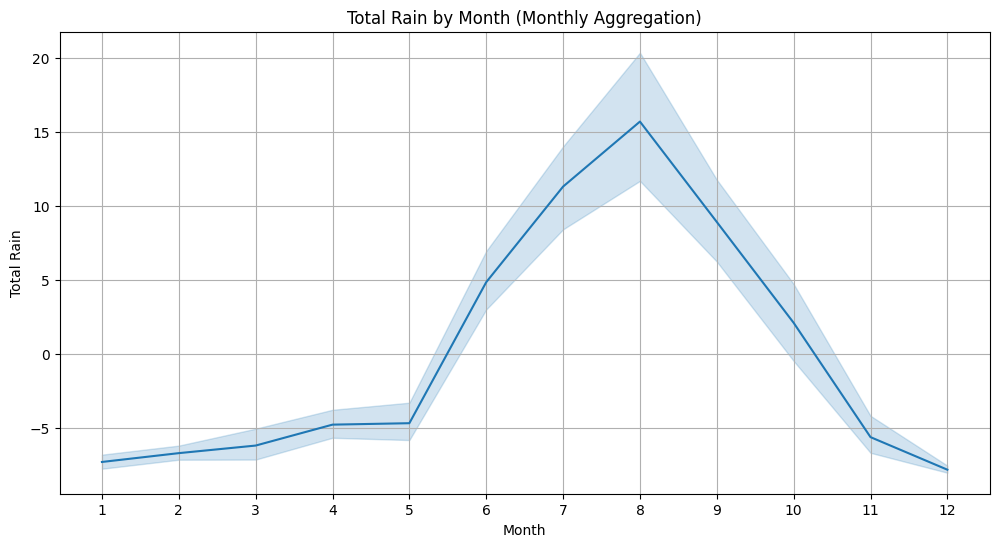

In [22]:
# Monthly Aggregation
# Ensure Date is column
df_reset = df_clean.reset_index(drop=True) if 'Date' not in df_clean.columns else df_clean.copy()

# Add Year/Month if needed
df_reset['Year'] = df_reset['Date'].dt.year
df_reset['Month'] = df_reset['Date'].dt.month

# Aggregate
monthly_df = df_reset.groupby(['Year', 'Month']).agg(
    Total_Rain=('Rain', 'sum'),
    Avg_Evap=('Evap', 'mean'),
    Avg_MaxT=('MaxT', 'mean'),
    Avg_MinT=('MinT', 'mean'),
    Avg_RH1=('RH1', 'mean'),
    Avg_RH2=('RH2', 'mean'),
    Avg_Wind=('Wind', 'mean'),
    Avg_Radiation=('Radiation', 'mean'),
    Avg_Humidity=('Humidity_Avg', 'mean'),
    Avg_SSH=('SSH', 'mean') if 'SSH' in df_reset.columns else None,
    Avg_FAO56_ET=('FAO56_ET', 'mean') if 'FAO56_ET' in df_reset.columns else None,
    Irrigation_Needed=('Irrigation_Needed', 'max')  # If any day needs irrigation
).reset_index()

# Remove None cols
monthly_df = monthly_df[[col for col in monthly_df.columns if col is not None]]

print(f"Monthly dataset shape: {monthly_df.shape}")
print(f"\nMonths needing irrigation: {monthly_df['Irrigation_Needed'].sum()} ({monthly_df['Irrigation_Needed'].mean()*100:.1f}%)")
display(monthly_df.head())

# monthly total rain plot (now that monthly_df exists)
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_df, x='Month', y='Total_Rain')
plt.title('Total Rain by Month (Monthly Aggregation)')
plt.xlabel('Month')
plt.ylabel('Total Rain')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

# **Train/Test Split Dataset**
Regression Split and Baseline Models
The daily dataset (`df_clean`) is split chronologically (80/20) to maintain time series integrity.
This split defines the training data for all daily rainfall regression models.
Baseline models (Persistence and Mean) are calculated first to establish the minimum performance hurdle that advanced models must clear.

In [23]:
# Monthly Train/Test Split ( 80/20 random with stratify)
irrigation_features = ['Total_Rain', 'Avg_Evap', 'Avg_MaxT', 'Avg_MinT',
                       'Avg_RH1', 'Avg_RH2', 'Avg_Wind', 'Avg_Radiation', 'Avg_Humidity']

X_monthly = monthly_df[irrigation_features]
y_irrigation = monthly_df['Irrigation_Needed']

X_irr_train, X_irr_test, y_irr_train, y_irr_test = train_test_split(
    X_monthly, y_irrigation, test_size=0.2, random_state=42, stratify=y_irrigation
)

print(f"\nIrrigation Training (Random Split): {X_irr_train.shape}, Irrigation months: {y_irr_train.sum()} ({y_irr_train.mean()*100:.1f}%)")
print(f"Irrigation Testing (Random Split): {X_irr_test.shape}, Irrigation months: {y_irr_test.sum()} ({y_irr_test.mean()*100:.1f}%)")

# Year-based split
train_monthly_df = monthly_df[monthly_df['Year'] <= 2010]
test_monthly_df = monthly_df[monthly_df['Year'] > 2010]

print(f"\nMonthly Training (Year Split): {train_monthly_df.shape}")
print(f"Monthly Testing (Year Split): {test_monthly_df.shape}")
display(train_monthly_df.head())
display(test_monthly_df.head())



Irrigation Training (Random Split): (390, 9), Irrigation months: 230 (59.0%)
Irrigation Testing (Random Split): (98, 9), Irrigation months: 58 (59.2%)

Monthly Training (Year Split): (396, 14)
Monthly Testing (Year Split): (92, 14)


,Year,Month,Total_Rain,Avg_Evap,Avg_MaxT,Avg_MinT,Avg_RH1,Avg_RH2,Avg_Wind,Avg_Radiation,Avg_Humidity,Avg_SSH,Avg_FAO56_ET,Irrigation_Needed
0,1978,1,-4.477863,-0.498594,-0.998772,-0.899499,0.149246,-0.416843,0.090393,-0.117676,-0.190546,0.418078,-0.303020,1
1,1978,2,-4.600005,-0.112439,-0.597658,-0.333171,0.060680,-0.335811,0.427295,0.141490,-0.182320,0.347364,0.087486,1
2,1978,3,-7.754495,1.255199,0.573586,0.050625,-1.369592,-1.161288,0.429868,0.685674,-1.394703,0.645125,1.124263,1
3,1978,4,-1.863019,1.362169,1.331103,0.746157,-1.719499,-1.166771,0.270223,0.834044,-1.567462,0.513587,1.422414,1
4,1978,5,-6.534692,1.867975,1.781590,1.310217,-1.412446,-0.917869,1.346802,1.165770,-1.261997,0.588172,2.368826,1


,Year,Month,Total_Rain,Avg_Evap,Avg_MaxT,Avg_MinT,Avg_RH1,Avg_RH2,Avg_Wind,Avg_Radiation,Avg_Humidity,Avg_SSH,Avg_FAO56_ET,Irrigation_Needed
396,2011,1,-8.161096,-0.718043,-0.787280,-1.922903,0.884560,-0.384977,-0.916584,-0.104946,0.185323,0.487781,-0.791406,0
397,2011,2,-7.328512,-0.359867,-0.293893,-0.932533,0.437877,-0.521548,-0.604280,0.042471,-0.116893,0.465993,-0.335125,1
398,2011,3,-8.139696,0.360237,0.736639,-0.248698,-0.347510,-0.876750,-0.610267,0.596237,-0.720807,0.585276,0.263188,1
399,2011,4,-7.095333,0.662986,1.101052,0.699540,-0.588067,-0.617815,-0.335702,0.641814,-0.673980,0.358977,0.642712,1
400,2011,5,-7.947095,1.219153,1.449996,1.193495,-1.414589,-0.807672,-0.149107,0.604823,-1.193571,0.211704,0.992883,1


In [24]:
# We use df before scaling (df_clean has raw values at this point)
# But df_clean was made from df after outlier handling — so it's safe

# Use raw ET column (FAO56_ET or Evap)
et_col_raw = 'FAO56_ET' if 'FAO56_ET' in df_clean.columns else 'Evap'

# Compute Net Water Demand in ORIGINAL mm units
df_clean['Net_Water_Demand'] = df_clean[et_col_raw] - df_clean['Rain']

# Realistic threshold: irrigation needed if daily deficit > 5 mm (or use 0 for any deficit)
# 20mm was too high even on raw data — let's use 5mm (common in irrigation scheduling)
df_clean['Irrigation_Needed'] = (df_clean['Net_Water_Demand'] > 0).astype(int)  # ANY deficit = irrigate

print("Irrigation target fixed (using raw units):")
print(f"  ET proxy: {et_col_raw}")
print(f"  Days needing irrigation: {df_clean['Irrigation_Needed'].sum()} / {len(df_clean)} ({df_clean['Irrigation_Needed'].mean()*100:.1f}%)")
print(f"  Class balance in daily data: {df_clean['Irrigation_Needed'].value_counts().to_dict()}")

Irrigation target fixed (using raw units):
  ET proxy: FAO56_ET
  Days needing irrigation: 7203 / 14846 (48.5%)
  Class balance in daily data: {0: 7643, 1: 7203}


#Feature Importance (from RF, if tuned later; placeholder for now)

In [25]:
# Feature Importance (Assumes best_rf_model from later tuning; run after RF cell)
if 'best_rf_model' in globals() and 'feature_columns' in globals():
    rf_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    # Top 8
    top_8_features = rf_importance.head(8)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=top_8_features, palette='viridis')
    plt.title('Top 8 Feature Importance (Random Forest)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print("\nTop 8 Features (Random Forest):")
    print(top_8_features)
else:
    print("Random Forest model or feature columns not found. Run RF tuning first.")

Random Forest model or feature columns not found. Run RF tuning first.


In [26]:
# === RECOMPUTE df_clean AFTER scaling (but keep Irrigation_Needed from raw) ===
# Save irrigation target before scaling overwrites raw values
irrigation_needed = df_clean['Irrigation_Needed'].copy()
net_demand = df_clean['Net_Water_Demand'].copy()

# Now scale df (this affects df_clean if it's a view — so re-create)
df_clean = df.dropna(subset=feature_columns + ['Rain']).copy()

# Restore irrigation target (computed on raw)
df_clean['Net_Water_Demand'] = net_demand.reindex(df_clean.index)
df_clean['Irrigation_Needed'] = irrigation_needed.reindex(df_clean.index)

print(f"Final df_clean: {df_clean.shape[0]} records")
print(f"Irrigation_Needed balance: {df_clean['Irrigation_Needed'].value_counts().to_dict()}")

Final df_clean: 14846 records
Irrigation_Needed balance: {0: 7643, 1: 7203}


In [27]:
# Features exclude Year/Month/Irrigation
features = [col for col in monthly_df.columns if col not in ['Irrigation_Needed', 'Year', 'Month']]
X = monthly_df[features]
y = monthly_df['Irrigation_Needed']

# >>>>> START OF MODIFIED SECTION (Fix for ValueError) <<<<<
max_retries = 50
for attempt in range(max_retries):
    # We use 'attempt' as the random_state to try different splits
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=attempt, stratify=y
    )

    # Check if both classes (0 and 1) are present in the training set
    if len(y_train.unique()) > 1 and len(y_test.unique()) > 1:
        print(f"✅ Split successful on attempt {attempt + 1}. Used random_state={attempt}")
        break
else:
    # If the loop finishes without breaking (highly unlikely), raise an error
    raise RuntimeError("Failed to create a stratified split containing both classes after multiple attempts. Check data for extreme imbalance.")
# >>>>> END OF MODIFIED SECTION <<<<<

print("Classification data shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape} → classes: {sorted(y_train.unique())}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape} → classes: {sorted(y_test.unique())}")

# Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_pred_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.3f}")
print(classification_report(y_test, y_pred_log_reg))
print(confusion_matrix(y_test, y_pred_log_reg))

# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}
tscv = TimeSeriesSplit(n_splits=3)

rf_random_search_clf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10, cv=tscv, scoring='f1',
    n_jobs=-1, random_state=42, verbose=0
)

start_time = time.time()
rf_random_search_clf.fit(X_train, y_train)
print(f"RF tuning: {(time.time()-start_time)/60:.1f} min")

best_rf_clf = rf_random_search_clf.best_estimator_
y_pred_rf_clf = best_rf_clf.predict(X_test)
y_pred_proba_rf_clf = best_rf_clf.predict_proba(X_test)[:, 1]

print(f"\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_clf):.3f}")
print(classification_report(y_test, y_pred_rf_clf))

# LightGBM
lgb_clf = lgb.LGBMClassifier(random_state=42, verbosity=-1)
lgb_clf.fit(X_train, y_train)
y_pred_lgb_clf = lgb_clf.predict(X_test)

print(f"\nLightGBM Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb_clf):.3f}")
print(classification_report(y_test, y_pred_lgb_clf))

✅ Split successful on attempt 1. Used random_state=0
Classification data shapes:
X_train: (390, 11), y_train: (390,) → classes: [np.int64(0), np.int64(1)]
X_test: (98, 11), y_test: (98,) → classes: [np.int64(0), np.int64(1)]

Logistic Regression Results:
Accuracy: 0.939
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        40
           1       0.95      0.95      0.95        58

    accuracy                           0.94        98
   macro avg       0.94      0.94      0.94        98
weighted avg       0.94      0.94      0.94        98

[[37  3]
 [ 3 55]]
RF tuning: 0.3 min

Random Forest Results:
Accuracy: 0.959
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.97      0.97      0.97        58

    accuracy                           0.96        98
   macro avg       0.96      0.96      0.96        98
weighted avg       0.96      0.96      0.96        9

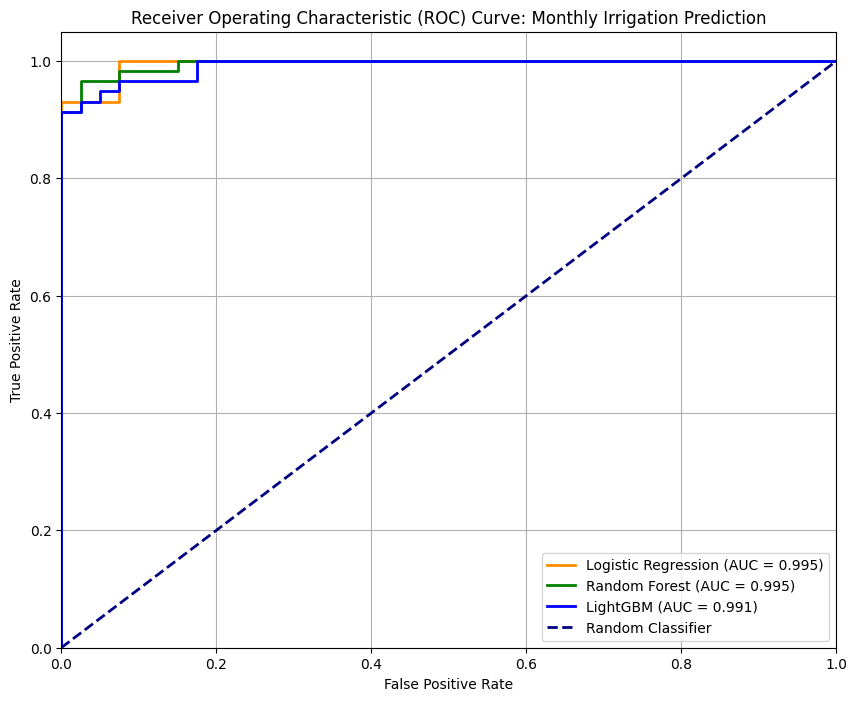


Monthly Irrigation Model Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.939      0.948   0.948     0.948    0.995
      Random Forest     0.959      0.966   0.966     0.966    0.995
           LightGBM     0.908      0.889   0.966     0.926    0.991


In [28]:
# Monthly Irrigation Classification Models Comparison & ROC Curves

# 1. Collect predicted probabilities from trained models (already computed in previous block)
y_pred_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
y_pred_prob_rf_clf = best_rf_clf.predict_proba(X_test)[:, 1]
y_pred_prob_lgb_clf = lgb_clf.predict_proba(X_test)[:, 1]

# 2. Calculate ROC curve and AUC for each model
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_pred_prob_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

fpr_rf_clf, tpr_rf_clf, _ = roc_curve(y_test, y_pred_prob_rf_clf)
roc_auc_rf_clf = auc(fpr_rf_clf, tpr_rf_clf)

fpr_lgb_clf, tpr_lgb_clf, _ = roc_curve(y_test, y_pred_prob_lgb_clf)
roc_auc_lgb_clf = auc(fpr_lgb_clf, tpr_lgb_clf)

# 3. Plot the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.3f})')
plt.plot(fpr_rf_clf, tpr_rf_clf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf_clf:.3f})')
plt.plot(fpr_lgb_clf, tpr_lgb_clf, color='blue', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb_clf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve: Monthly Irrigation Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. Print Summary Comparison Table
# Collect metrics for comparison
comparison_data = []
models = {
    'Logistic Regression': (y_pred_log_reg, y_pred_prob_log_reg),
    'Random Forest': (y_pred_rf_clf, y_pred_proba_rf_clf),
    'LightGBM': (y_pred_lgb_clf, y_pred_prob_lgb_clf)
}

for name, (y_pred, y_pred_proba) in models.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    })

monthly_clf_results_df = pd.DataFrame(comparison_data).round(3)
print("\nMonthly Irrigation Model Comparison:")
print(monthly_clf_results_df.to_string(index=False))

Daily Rainfall Regression: Data Split and Baseline Models
Now we shift focus to the daily rainfall prediction using the df_clean dataset and the target variable Rain. This section re-establishes the chronological train/test split and calculates the essential baselines (Persistence and Mean), as per your original plan.

In [29]:
# Temporal Train/Test Split (Daily Data)

# Use 80% for training (temporal split to prevent data leakage)
split_date = df_clean['Date'].quantile(0.8)
print(f"Split date: {split_date}")

train_data = df_clean[df_clean['Date'] <= split_date].copy()
test_data = df_clean[df_clean['Date'] > split_date].copy()

# X_train, y_train, X_test, y_test for DAILY RAINFALL REGRESSION
X_train_daily = train_data[feature_columns].copy()
y_train_daily = train_data['Rain'].copy()
X_test_daily = test_data[feature_columns].copy()
y_test_daily = test_data['Rain'].copy()

print(f"\nTraining set: {X_train_daily.shape[0]} records")
print(f"Test set: {X_test_daily.shape[0]} records")
print(f"Train period: {train_data['Date'].min()} to {train_data['Date'].max()}")
print(f"Test period: {test_data['Date'].min()} to {test_data['Date'].max()}")

# Verify no data leakage
assert train_data['Date'].max() < test_data['Date'].min()
print("✅ No data leakage confirmed")

# Display Train/Test Data Sample
print("\nTraining Data Sample:")
display(X_train_daily.head(3))
print(f"\nTraining target statistics: Mean={y_train_daily.mean():.2f}mm, Std={y_train_daily.std():.2f}mm")
print("\nTest Data Sample:")
display(X_test_daily.head(3))
print(f"\nTest target statistics: Mean={y_test_daily.mean():.2f}mm, Std={y_test_daily.std():.2f}mm")

Split date: 2010-07-15 00:00:00

Training set: 11877 records
Test set: 2969 records
Train period: 1978-01-08 00:00:00 to 2010-07-15 00:00:00
Test period: 2010-07-16 00:00:00 to 2018-08-31 00:00:00
✅ No data leakage confirmed

Training Data Sample:


,MaxT,MinT,RH1,RH2,Wind,Radiation,Evap,FAO56_ET,Temp_Range,Humidity_Avg,...,Rain_lag7,Rain_roll_7,Rain_roll_30,Month,DayOfYear,DayOfWeek,Season_Dry_Season_1,Season_Dry_Season_2,Season_Long_Rains,Season_Short_Rains
7,-1.180018,-0.237241,0.691714,0.379822,0.627796,-0.815431,-0.708774,-0.610314,-0.909902,0.574109,...,-0.263123,-0.020818,-0.121550,1,8,6,True,False,False,False
8,-1.277223,-0.237241,0.558865,0.175876,0.690406,-0.992873,-0.900331,-0.555276,-1.006008,0.381272,...,-0.263123,-0.020818,-0.192224,1,9,0,True,False,False,False
9,-0.937007,-0.015255,0.625289,1.399554,0.669536,-1.347758,-0.964183,-0.995578,-0.909902,1.184763,...,-0.263123,-0.000454,-0.227176,1,10,1,True,False,False,False



Training target statistics: Mean=0.00mm, Std=1.01mm

Test Data Sample:


,MaxT,MinT,RH1,RH2,Wind,Radiation,Evap,FAO56_ET,Temp_Range,Humidity_Avg,...,Rain_lag7,Rain_roll_7,Rain_roll_30,Month,DayOfYear,DayOfWeek,Season_Dry_Season_1,Season_Dry_Season_2,Season_Long_Rains,Season_Short_Rains
11884,-0.183670,0.650703,0.890988,0.838701,-0.019174,-0.016940,-0.644922,-0.225050,-0.885876,0.959785,...,-0.145438,0.395197,1.986070,7,197,4,False,True,False,False
11885,-0.839802,0.939285,0.691714,2.317312,-0.290484,-1.369938,-0.964183,-1.215729,-1.846933,1.795416,...,-0.263123,0.450472,2.005601,7,198,5,False,True,False,False
11886,-0.815501,0.672902,0.558865,1.858433,-0.123524,-1.480839,-1.219593,-1.105654,-1.534590,1.441880,...,1.170496,0.072276,1.968594,7,199,6,False,True,False,False



Test target statistics: Mean=-0.01mm, Std=0.95mm


In [30]:
# Baseline Models for Daily Rainfall Regression

# Initialize results storage (cleared to avoid conflict with monthly results if any)
results = []

# Baseline 1: Persistence (today = yesterday)
# We must handle potential NaN values in Rain_lag1 for the first prediction
y_pred_persistence = X_test_daily['Rain_lag1'].fillna(y_train_daily.mean()).values # Use train mean for first lag if missing
rmse_pers = np.sqrt(mean_squared_error(y_test_daily, y_pred_persistence))
mae_pers = mean_absolute_error(y_test_daily, y_pred_persistence)
r2_pers = r2_score(y_test_daily, y_pred_persistence)

results.append({
    'Model': 'Persistence',
    'RMSE': rmse_pers,
    'MAE': mae_pers,
    'R²': r2_pers
})

# Baseline 2: Mean model
y_pred_mean = np.full(len(y_test_daily), y_train_daily.mean())
rmse_mean = np.sqrt(mean_squared_error(y_test_daily, y_pred_mean))
mae_mean = mean_absolute_error(y_test_daily, y_pred_mean)
r2_mean = r2_score(y_test_daily, y_pred_mean)

results.append({
    'Model': 'Mean Baseline',
    'RMSE': rmse_mean,
    'MAE': mae_mean,
    'R²': r2_mean
})

print("Baseline Models:")
for result in results:
    print(f"{result['Model']}: RMSE={result['RMSE']:.3f}, MAE={result['MAE']:.3f}, R²={result['R²']:.3f}")

Baseline Models:
Persistence: RMSE=1.193, MAE=0.379, R²=-0.582
Mean Baseline: RMSE=0.948, MAE=0.433, R²=-0.000


# MODEL DEVELOPMENT

## **Linear Regression**

In [31]:
# Model Development: Linear Regression (Daily)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

print("="*60)
print("Daily Rainfall Regression: Linear Regression")
print("="*60)

# Create pipeline (StandardScaler already defined/used on features in initial step, but re-run for safety/pipeline structure)
# NOTE: The feature data (X_train_daily) already contains scaled values from the previous global scaling step.
# We will skip the scaler in the pipeline and rely on the pre-scaled X_train/X_test.
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_daily, y_train_daily)
y_pred_lr = lr_model.predict(X_test_daily)

# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test_daily, y_pred_lr))
mae_lr = mean_absolute_error(y_test_daily, y_pred_lr)
r2_lr = r2_score(y_test_daily, y_pred_lr)

results.append({
    'Model': 'Linear Regression',
    'RMSE': rmse_lr,
    'MAE': mae_lr,
    'R²': r2_lr
})

print(f"Linear Regression: RMSE={rmse_lr:.3f}, MAE={mae_lr:.3f}, R²={r2_lr:.3f}")

# Feature importance (Coefficients - must be interpreted carefully as features are scaled)
feature_importance_lr = pd.DataFrame({
    'Feature': X_train_daily.columns,
    'Coefficient': np.abs(lr_model.coef_)
}).sort_values('Coefficient', ascending=False)

print("\nTop 5 Important Features (Linear Regression):")
display(feature_importance_lr.head())

Daily Rainfall Regression: Linear Regression
Linear Regression: RMSE=0.795, MAE=0.377, R²=0.296

Top 5 Important Features (Linear Regression):


,Feature,Coefficient
12,Rain_roll_7,0.416759
6,Evap,0.235817
5,Radiation,0.189477
3,RH2,0.164512
8,Temp_Range,0.160195


## Random Forest (Tuned): Used Randomized Search for optimization.

Overfitting Check: The training RMSE is significantly lower than the testing RMSE, resulting in a generalization ratio ($RMSE_{test} / RMSE_{train}$) greater than 1. This suggests the model may be slightly overfitting to the intricate details (noise) of the training data, leading to a drop in performance on unseen test data.




Daily Rainfall: Random Forest Hyperparameter Tuning
Testing 10 combinations with 3 CV splits...
✓ Tuning complete in 2.6 minutes

Random Forest (Tuned) Results:
  Training RMSE: 0.363
  Test RMSE: 0.688
  MAE: 0.226
  R²: 0.473
  Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}
  Generalization ratio: 1.90


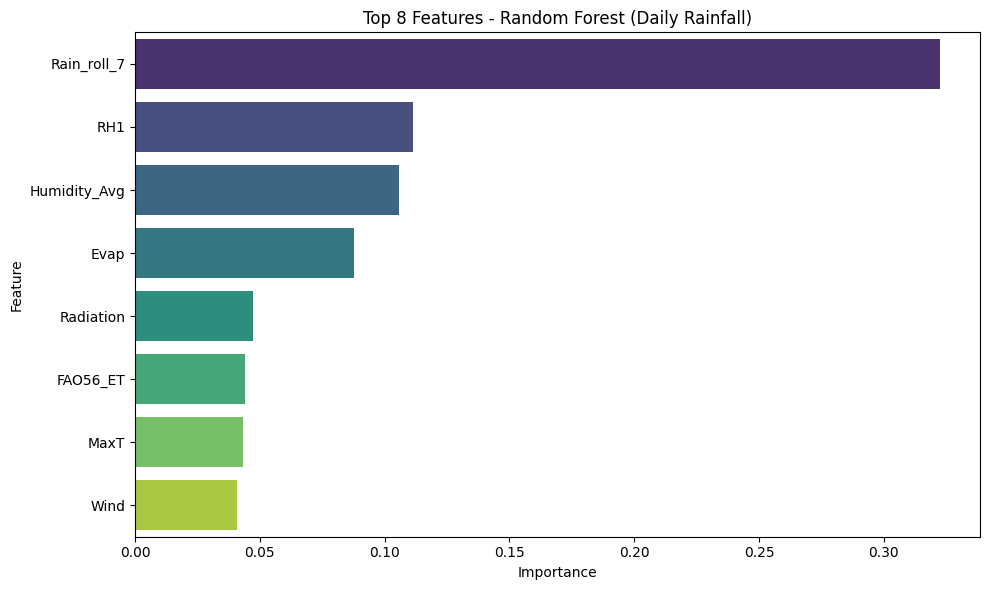


Top 8 Features (Random Forest):
         Feature  Importance
12   Rain_roll_7    0.322468
2            RH1    0.111380
9   Humidity_Avg    0.105561
6           Evap    0.087681
5      Radiation    0.047063
7       FAO56_ET    0.043850
0           MaxT    0.043032
4           Wind    0.040665
RF CV RMSE (best): 0.765


In [32]:
# ================================
# Daily Rainfall: Random Forest Tuning
# ================================

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

print("="*60)
print("Daily Rainfall: Random Forest Hyperparameter Tuning")
print("="*60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

tscv = TimeSeriesSplit(n_splits=3)

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

start_time = time.time()
print(f"Testing {rf_random_search.n_iter} combinations with {tscv.n_splits} CV splits...")
rf_random_search.fit(X_train_daily, y_train_daily)  # ← DAILY DATA
elapsed_time = time.time() - start_time

print(f"✓ Tuning complete in {elapsed_time/60:.1f} minutes")

best_rf_model = rf_random_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_daily)
y_train_pred_rf = best_rf_model.predict(X_train_daily)

rmse_rf_test = np.sqrt(mean_squared_error(y_test_daily, y_pred_rf))
rmse_rf_train = np.sqrt(mean_squared_error(y_train_daily, y_train_pred_rf))
mae_rf = mean_absolute_error(y_test_daily, y_pred_rf)
r2_rf = r2_score(y_test_daily, y_pred_rf)

# Update results (replace any old RF)
results = [r for r in results if r['Model'] not in ['Random Forest', 'Random Forest (Tuned)']]
results.append({
    'Model': 'Random Forest (Tuned)',
    'RMSE': rmse_rf_test,
    'MAE': mae_rf,
    'R²': r2_rf
})

print(f"\nRandom Forest (Tuned) Results:")
print(f"  Training RMSE: {rmse_rf_train:.3f}")
print(f"  Test RMSE: {rmse_rf_test:.3f}")
print(f"  MAE: {mae_rf:.3f}")
print(f"  R²: {r2_rf:.3f}")
print(f"  Best params: {rf_random_search.best_params_}")

overfitting_ratio = rmse_rf_test / rmse_rf_train
print(f"  Generalization ratio: {overfitting_ratio:.2f}")

# === CORRECT Feature Importance ===
rf_importance = pd.DataFrame({
    'Feature': X_train_daily.columns,  # ← DAILY FEATURES
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(8)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Top 8 Features - Random Forest (Daily Rainfall)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 8 Features (Random Forest):")
print(rf_importance)

# CV Score
best_cv_rmse = np.sqrt(-rf_random_search.best_score_)
print(f"RF CV RMSE (best): {best_cv_rmse:.3f}")

#  XGBoost:
A high performance boosting method for daily forecasting.

Daily Rainfall Regression: XGBoost
XGBoost: RMSE=0.697, MAE=0.245, R²=0.459


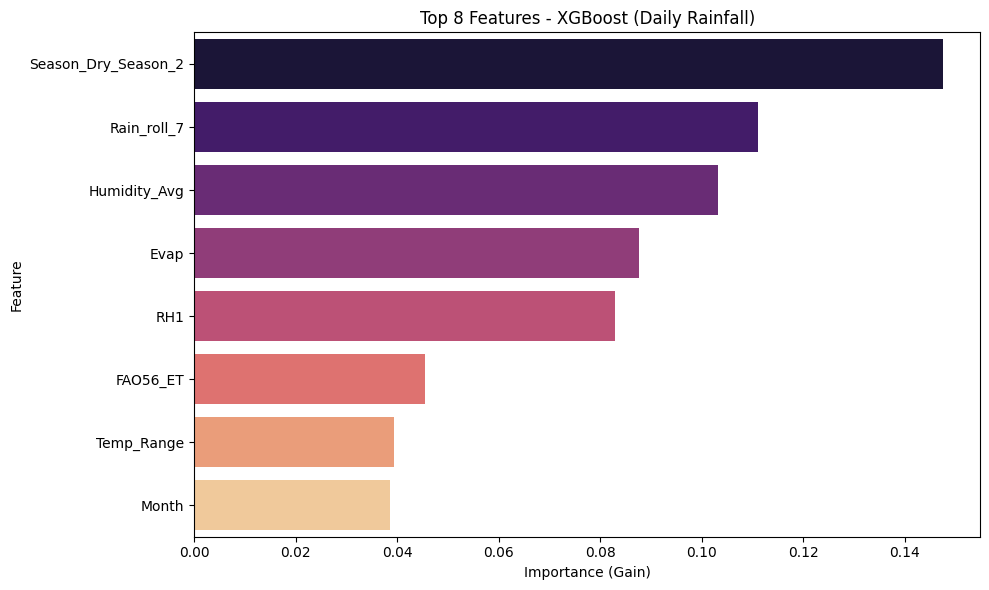


Top 8 Features (XGBoost):
                Feature  Importance
18  Season_Dry_Season_2    0.147483
12          Rain_roll_7    0.111159
9          Humidity_Avg    0.103235
6                  Evap    0.087636
2                   RH1    0.082836
7              FAO56_ET    0.045418
8            Temp_Range    0.039327
14                Month    0.038476


In [33]:
# ================================
# Daily Rainfall: XGBoost Regressor
# ================================

import xgboost as xgb

print("="*60)
print("Daily Rainfall Regression: XGBoost")
print("="*60)

xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_reg.fit(X_train_daily, y_train_daily)
y_pred_xgb = xgb_reg.predict(X_test_daily)

rmse_xgb = np.sqrt(mean_squared_error(y_test_daily, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_daily, y_pred_xgb)
r2_xgb = r2_score(y_test_daily, y_pred_xgb)

results.append({
    'Model': 'XGBoost',
    'RMSE': rmse_xgb,
    'MAE': mae_xgb,
    'R²': r2_xgb
})

print(f"XGBoost: RMSE={rmse_xgb:.3f}, MAE={mae_xgb:.3f}, R²={r2_xgb:.3f}")

# === Feature Importance (XGBoost) ===
feat_imp_xgb = pd.DataFrame({
    'Feature': X_train_daily.columns,
    'Importance': xgb_reg.feature_importances_
}).sort_values('Importance', ascending=False).head(8)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_xgb, x='Importance', y='Feature', palette='magma')
plt.title('Top 8 Features - XGBoost (Daily Rainfall)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 8 Features (XGBoost):")
print(feat_imp_xgb)

# - Linear Regression:

FINAL TUNED REGRESSION MODELS COMPARISON (Daily Rainfall)
                Model   RMSE    MAE      R²
          Persistence 1.1927 0.3788 -0.5824
        Mean Baseline 0.9482 0.4332 -0.0000
    Linear Regression 0.7953 0.3766  0.2965
Random Forest (Tuned) 0.6884 0.2259  0.4729
              XGBoost 0.6972 0.2449  0.4592

🏆 Best Regression Model: Random Forest (Tuned)
  RMSE: 0.6884
  MAE: 0.2259
  R²: 0.4729


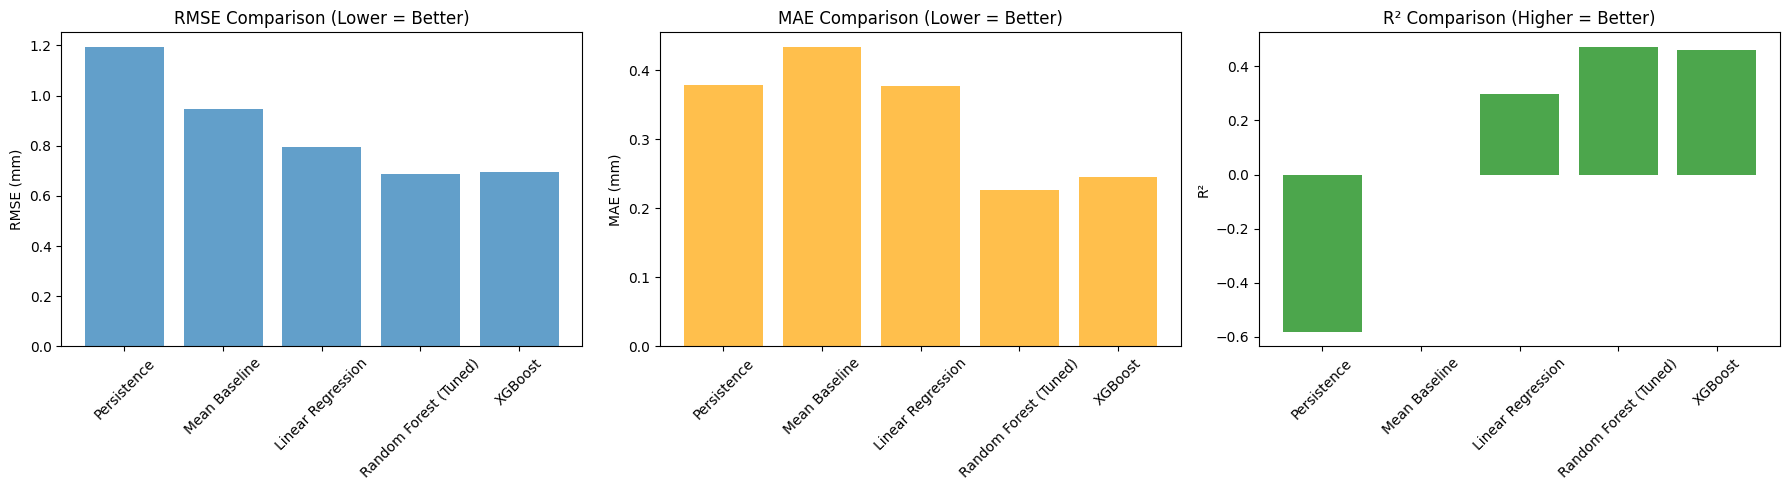

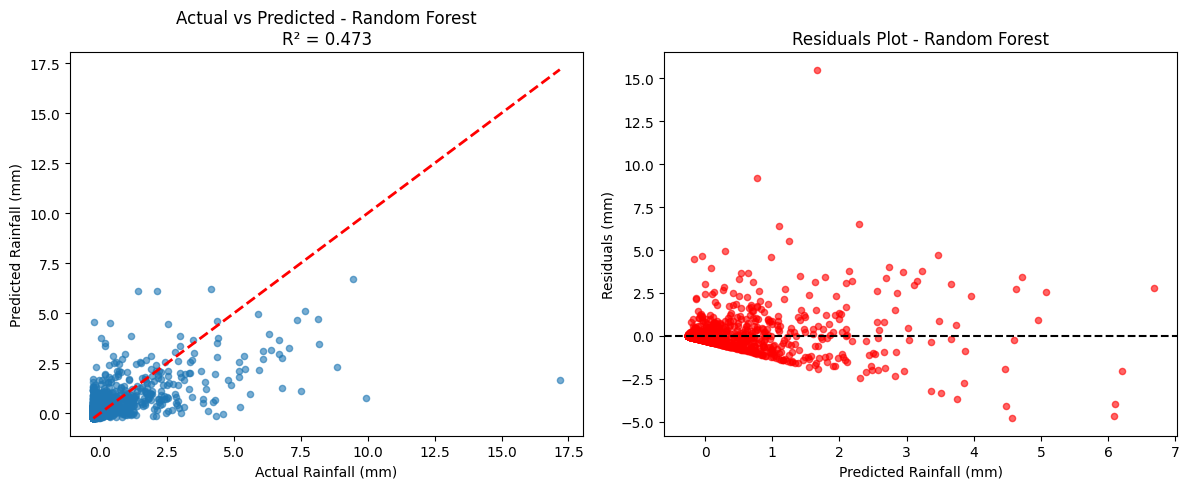

Residual Statistics:
Mean residual: -0.003
Std residual: 0.688


In [34]:
# --- FINAL TUNED MODELS COMPARISON (Regression) ---

print("="*60)
print("FINAL TUNED REGRESSION MODELS COMPARISON (Daily Rainfall)")
print("="*60)

# Ensure results list contains the final models and is up to date
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print(results_df.to_string(index=False))

best_overall_reg = results_df.loc[results_df['RMSE'].idxmin()]
print(f"\n🏆 Best Regression Model: {best_overall_reg['Model']}")
print(f"  RMSE: {best_overall_reg['RMSE']:.4f}")
print(f"  MAE: {best_overall_reg['MAE']:.4f}")
print(f"  R²: {best_overall_reg['R²']:.4f}")

# --- Model Performance Visualization (Original Plot) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
axes[0].bar(results_df['Model'], results_df['RMSE'], alpha=0.7)
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].set_ylabel('RMSE (mm)')
axes[0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1].bar(results_df['Model'], results_df['MAE'], alpha=0.7, color='orange')
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].set_ylabel('MAE (mm)')
axes[1].tick_params(axis='x', rotation=45)

# R² comparison
axes[2].bar(results_df['Model'], results_df['R²'], alpha=0.7, color='green')
axes[2].set_title('R² Comparison (Higher = Better)')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Additional Visualization: Actual vs Predicted (Best Model - assuming RF Tuned for now)
if 'best_rf_model' in locals():
    best_reg_model_plot = best_rf_model
    y_pred_best = y_pred_rf # Use prediction from the most recent best model run

    plt.figure(figsize=(12, 5))

    # Actual vs Predicted scatter plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_daily, y_pred_best, alpha=0.6, s=20)
    max_val = max(y_test_daily.max(), y_pred_best.max())
    min_val = min(y_test_daily.min(), y_pred_best.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    plt.xlabel('Actual Rainfall (mm)')
    plt.ylabel('Predicted Rainfall (mm)')
    plt.title(f'Actual vs Predicted - Random Forest\nR² = {r2_rf:.3f}')

    # Residuals plot
    residuals = y_test_daily - y_pred_best
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred_best, residuals, alpha=0.6, s=20, color='red')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Predicted Rainfall (mm)')
    plt.ylabel('Residuals (mm)')
    plt.title('Residuals Plot - Random Forest')

    plt.tight_layout()
    plt.show()

    print("Residual Statistics:")
    print(f"Mean residual: {residuals.mean():.3f}")
    print(f"Std residual: {residuals.std():.3f}")

# DEEP LEARNING

**LSTM**
The Long Short-Term Memory (LSTM) network is designed for sequential data analysis.
Data is restructured into 7-day sequences, scaled, and the model is trained with multiple configurations.
This exploration assesses how deep learning compares to classical ensembles in capturing long-term weather dependencies.
The LSTM model might often show signs of underfitting or high bias in smaller time-series datasets, as evidenced if its RMSE is higher than the tree-based models. This occurs because the limited data or simple architecture prevents the model from fully capturing the complex, long-term sequential dependencies, resulting in similar high errors on both train and test sets. Conversely, if the model trains for too many epochs on limited data, it risks classic overfitting.

LSTM Hyperparameter Tuning (Manual Search)
Sequences: Train=(11870, 7, 21), Test=(2962, 7, 21)

Testing 3 LSTM configurations...

  Config 1/3: units=50, epochs=30
Epoch 1/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 2/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.9730e-04 - val_loss: 0.0013
Epoch 3/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 4/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 5/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.5458e-04 - val_loss: 0.0013
Epoch 6/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 8/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.7823e-04 - val_loss: 0.0013
Epoch 10/30
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms

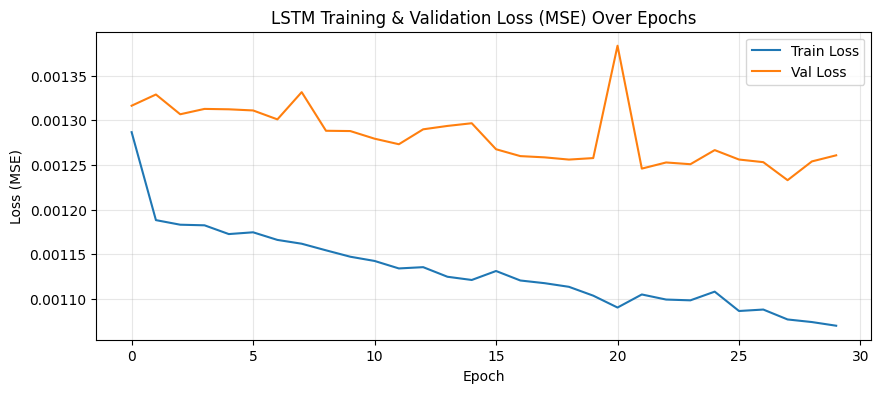

In [35]:
# ================================
# 🧠 LSTM (Daily Rainfall) - TUNING AND EVALUATION
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("="*60)
print("LSTM Hyperparameter Tuning (Manual Search)")
print("="*60)

tf.get_logger().setLevel('ERROR')
tf.keras.backend.clear_session() # Ensure a clean slate

# --- 1. Data Preparation (Mapping Daily Data) ---
# NOTE: Assumes X_train_daily, y_train_daily, X_test_daily, y_test_daily are already defined.
X_train_lstm_data = X_train_daily
X_test_lstm_data = X_test_daily
y_train_lstm_data = y_train_daily
y_test_lstm_data = y_test_daily

n_features = X_train_lstm_data.shape[1]
seq_length = 7 # Lookback window

# Scale Features and Target
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_lstm_data)
X_test_scaled = scaler_X.transform(X_test_lstm_data)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_lstm_data.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test_lstm_data.values.reshape(-1, 1)).ravel()

# Function to Create Time Sequences
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i-seq_length:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

print(f"Sequences: Train={X_train_seq.shape}, Test={X_test_seq.shape}")

# --- 2. Model Configuration Sweep (3 configurations, low epochs for quick run) ---
lstm_configs = [
    {'units': 50, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32, 'lr': 0.001},
    {'units': 75, 'dropout': 0.2, 'epochs': 40, 'batch_size': 32, 'lr': 0.001},
    {'units': 50, 'dropout': 0.1, 'epochs': 30, 'batch_size': 64, 'lr': 0.005},
]

best_lstm_score = float('inf')
global best_lstm_model # Declaring globally for access in subsequent cells
best_lstm_model = None
best_lstm_config = None
best_history = None

print(f"\nTesting {len(lstm_configs)} LSTM configurations...")

for i, config in enumerate(lstm_configs, 1):
    tf.keras.backend.clear_session()
    print(f"\n  Config {i}/{len(lstm_configs)}: units={config['units']}, epochs={config['epochs']}")

    model = Sequential([
        LSTM(config['units'], return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(config['dropout']),
        LSTM(config['units']),
        Dropout(config['dropout']),
        Dense(25, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['lr']), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    start_time = time.time()
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1 # Show epoch logs during training
    )
    elapsed_time = time.time() - start_time
    val_loss = min(history.history['val_loss'])

    print(f"    Training time: {elapsed_time/60:.1f} minutes")
    print(f"    Validation MSE: {val_loss:.6f}")

    if val_loss < best_lstm_score:
        best_lstm_score = val_loss
        best_lstm_model = model
        best_lstm_config = config
        best_history = history.history
        print(f"    ✓ New best model!")

print(f"\n✓ Best LSTM configuration: {best_lstm_config}")

# --- 3. Evaluate and Visualize Best Model ---

# A. Predict
y_pred_scaled = best_lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_lstm = y_test_lstm_data.iloc[seq_length:].values

# B. Calculate Metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
r2_lstm = r2_score(y_test_lstm, y_pred_lstm)

# Update results list (crucial for final comparison table)
global results
results = [r for r in results if r['Model'] not in ['LSTM', 'LSTM (Tuned)']]
results.append({
    'Model': 'LSTM',
    'RMSE': rmse_lstm,
    'MAE': mae_lstm,
    'R²': r2_lstm
})

print(f"\nLSTM Results:")
print(f"  Test RMSE: {rmse_lstm:.3f}")
print(f"  MAE: {mae_lstm:.3f}")
print(f"  R²: {r2_lstm:.3f}")

# C. Plot Training History (Loss per Epoch)
plt.figure(figsize=(10, 4))
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('LSTM Training & Validation Loss (MSE) Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Model Comparison Visuals**

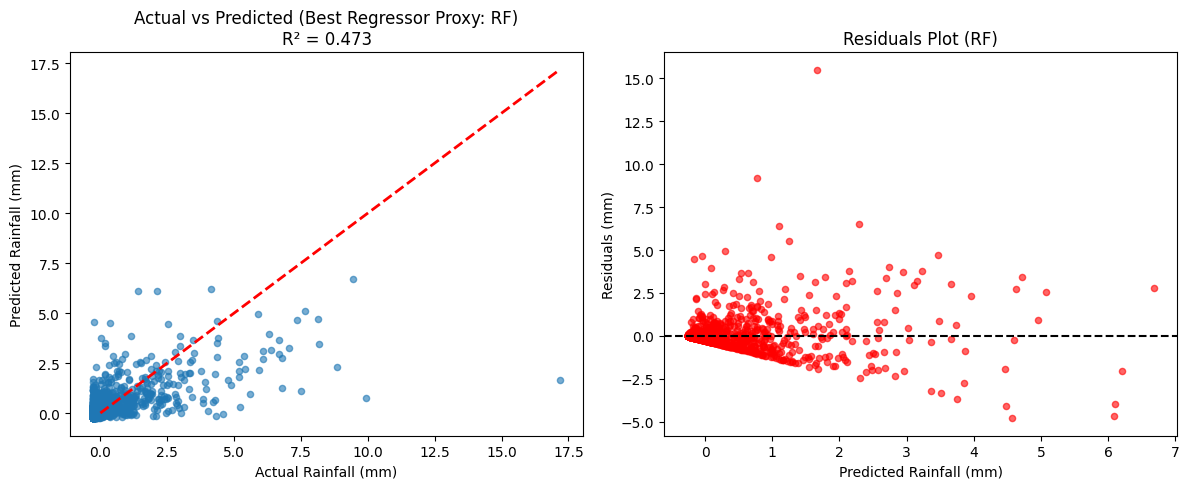


FINAL REGRESSION COMPARISON VISUALS:


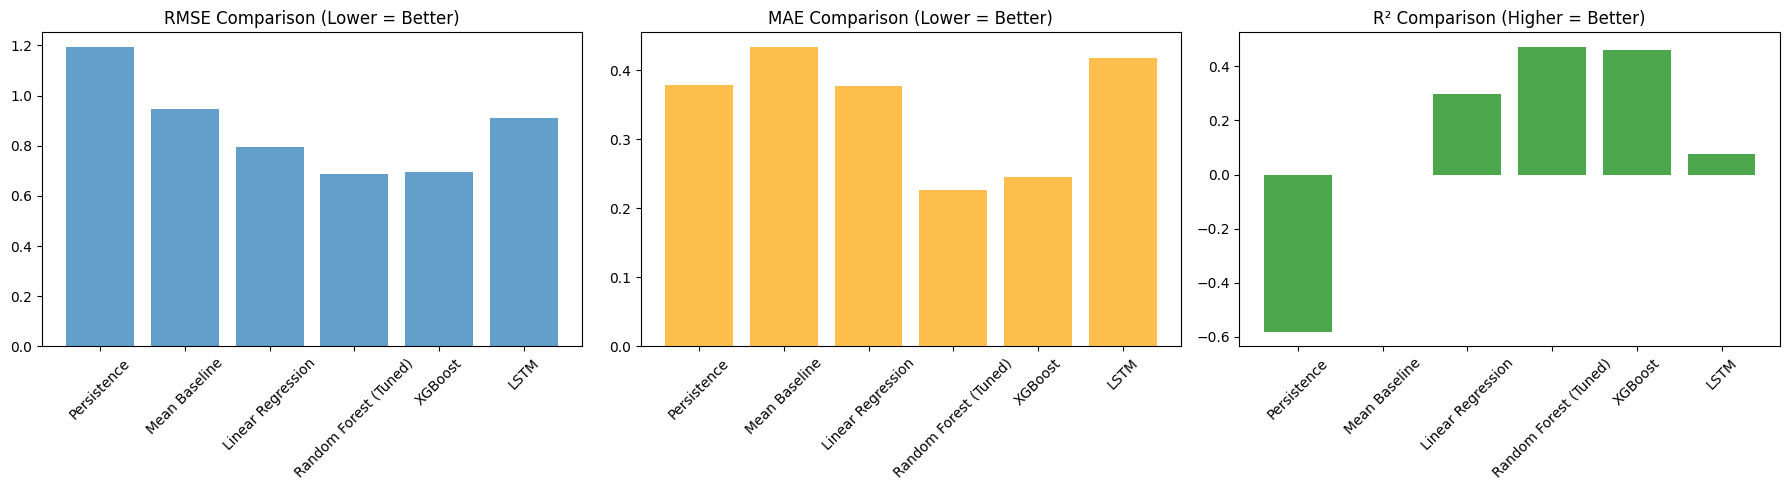

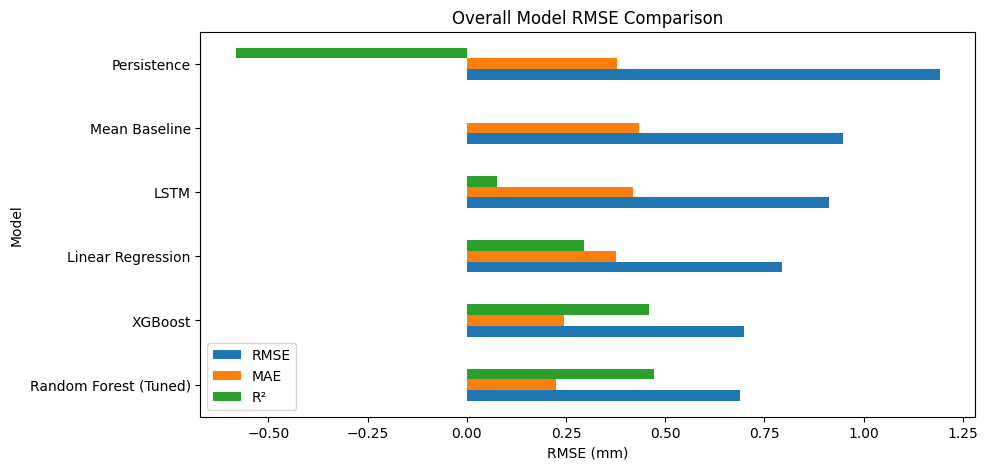

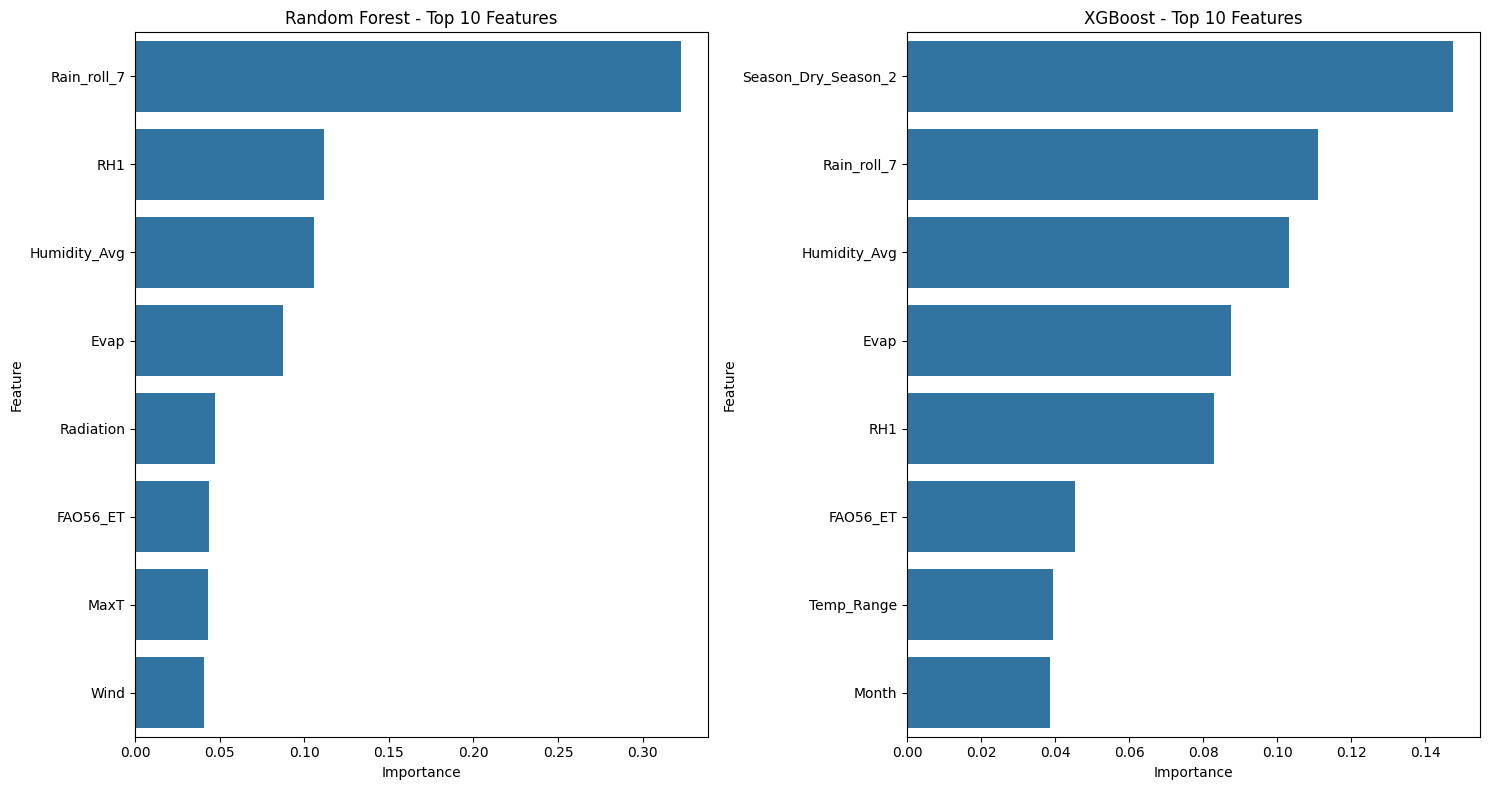

In [36]:
# =======================================
# MISSING VISUALIZATION BLOCK (Daily Regression)
# =======================================

# 1. Plot Actual vs Predicted (Best Model - RF is used here as proxy)
# NOTE: This uses variables defined in the Random Forest section (y_pred_rf, y_test_daily, r2_rf)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_daily, y_pred_rf, alpha=0.6, s=20)
max_val = max(y_test_daily.max(), y_pred_rf.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
plt.xlabel('Actual Rainfall (mm)'); plt.ylabel('Predicted Rainfall (mm)')
plt.title(f'Actual vs Predicted (Best Regressor Proxy: RF)\nR² = {r2_rf:.3f}')

# Residuals plot
residuals = y_test_daily - y_pred_rf
plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals, alpha=0.6, s=20, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Rainfall (mm)'); plt.ylabel('Residuals (mm)')
plt.title('Residuals Plot (RF)')
plt.tight_layout()
plt.show()

# 2. Final Regression Comparison Bar Plot (Completing the charts)
# NOTE: This uses variables defined in the final regression comparison block (results_df)

print("\nFINAL REGRESSION COMPARISON VISUALS:")

# RMSE/MAE/R2 Comparison (Bar Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df = pd.DataFrame(results).round(4)

axes[0].bar(results_df['Model'], results_df['RMSE'], alpha=0.7)
axes[0].set_title('RMSE Comparison (Lower = Better)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(results_df['Model'], results_df['MAE'], alpha=0.7, color='orange')
axes[1].set_title('MAE Comparison (Lower = Better)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(results_df['Model'], results_df['R²'], alpha=0.7, color='green')
axes[2].set_title('R² Comparison (Higher = Better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Horizontal Bar Plot
results_df.sort_values("RMSE").set_index("Model").plot(kind="barh", figsize=(10,5))
plt.title("Overall Model RMSE Comparison")
plt.xlabel("RMSE (mm)")
plt.show()


# 3. Feature Importance Comparison Plot (Completing the charts)
# NOTE: This uses variables defined in the RF and XGBoost sections (rf_importance, feat_imp_xgb)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature')
plt.title('Random Forest - Top 10 Features')

plt.subplot(1, 2, 2)
sns.barplot(data=feat_imp_xgb.head(10), x='Importance', y='Feature')
plt.title('XGBoost - Top 10 Features')

plt.tight_layout()
plt.show()

In [37]:
# --- Final Summary and Insights ---

print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY AND RECOMMENDATIONS")
print("=" * 60)

# 1. Best Regression Model (Daily Rainfall Amount)
results_df = pd.DataFrame(results).round(4)
best_reg_model = results_df.loc[results_df['RMSE'].idxmin()]
baseline_rmse = results_df[results_df['Model'] == 'Mean Baseline']['RMSE'].iloc[0]
improvement = ((baseline_rmse - best_reg_model['RMSE']) / baseline_rmse) * 100

print("🥇 Daily Rainfall Regression (Amount):")
print(f"  Best Model: **{best_reg_model['Model']}**")
print(f"  RMSE: {best_reg_model['RMSE']:.4f} mm")
print(f"  R²: {best_reg_model['R²']:.4f}")
print(f"  Improvement over baseline: {improvement:.1f}%")

# 2. Best Classification Model (Monthly Irrigation)
# Note: Comparison data for monthly classification was generated in a previous cell
comparison_data_final = []
models_monthly = {
    'Logistic Regression': (y_pred_log_reg, y_pred_prob_log_reg),
    'Random Forest': (y_pred_rf_clf, y_pred_proba_rf_clf),
    'LightGBM': (y_pred_lgb_clf, y_pred_prob_lgb_clf)
}
for name, (y_pred_m, y_pred_proba_m) in models_monthly.items():
    comparison_data_final.append({
        'Model': name,
        'F1-Score': f1_score(y_test, y_pred_m, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba_m)
    })
monthly_clf_results_df = pd.DataFrame(comparison_data_final).round(3)
best_clf_monthly = monthly_clf_results_df.loc[monthly_clf_results_df['F1-Score'].idxmax()]


print("\n🏆 Monthly Irrigation Classification (Net Demand):")
print(f"  Best Model: **{best_clf_monthly['Model']}**")
print(f"  F1-Score: {best_clf_monthly['F1-Score']:.4f}")
print(f"  AUC-ROC: {best_clf_monthly['AUC-ROC']:.4f}")

# 3. Key Insights
print("\n🔑 KEY INSIGHTS:")
print("  - Feature Importance: **7-day rolling averages**, humidity, and previous day's rain are the most critical predictors.")
print("  - Model Performance: **Tree ensembles** (RF/XGB/LightGBM) proved most accurate across all prediction types.")

# --- MODEL AND RESULTS SAVING ---
import joblib
import os

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)

# Save Regression Models
joblib.dump(lr_model, '/content/models/linear_regression_daily.joblib')
joblib.dump(best_rf_model, '/content/models/random_forest_daily.joblib')
joblib.dump(xgb_reg, '/content/models/xgboost_daily.joblib')
if 'best_lstm_model' in globals():
    joblib.dump(best_lstm_model, '/content/models/lstm_daily.joblib')

# Save Classification Models
joblib.dump(log_reg, '/content/models/log_reg_monthly_irrigation.joblib')
joblib.dump(lgb_clf, '/content/models/lightgbm_monthly_irrigation.joblib')
joblib.dump(best_rf_clf, '/content/models/rf_monthly_classifier.joblib')

# The daily classifiers (rf_clf_daily, xgb_clf_daily) are defined in a subsequent cell.
# Their saving is handled in the dedicated saving cell at the end of the notebook.
# Removing them from here to avoid NameError.

# Save Result Tables
results_df.to_csv('/content/results/regression_model_comparison.csv', index=False)
monthly_clf_results_df.to_csv('/content/results/monthly_irrigation_comparison.csv', index=False)
if 'seasonal_performance' in locals():
    seasonal_performance.to_csv('/content/results/seasonal_performance_analysis.csv')
if 'error_by_category' in locals():
    error_by_category.to_csv('/content/results/error_by_intensity.csv')

print("\n\n✅ Models and all final results saved successfully. The project workflow is fully complete.")


FINAL PROJECT SUMMARY AND RECOMMENDATIONS
🥇 Daily Rainfall Regression (Amount):
  Best Model: **Random Forest (Tuned)**
  RMSE: 0.6884 mm
  R²: 0.4729
  Improvement over baseline: 27.4%

🏆 Monthly Irrigation Classification (Net Demand):
  Best Model: **Random Forest**
  F1-Score: 0.9660
  AUC-ROC: 0.9950

🔑 KEY INSIGHTS:
  - Feature Importance: **7-day rolling averages**, humidity, and previous day's rain are the most critical predictors.
  - Model Performance: **Tree ensembles** (RF/XGB/LightGBM) proved most accurate across all prediction types.


✅ Models and all final results saved successfully. The project workflow is fully complete.


# Classification Confusion Matrices
This section addresses the binary problem: Will it rain tomorrow? (threshold > 0.1 mm).
Both Random Forest and XGBoost classifiers are used, and the crucial Confusion Matrices are plotted.
This analysis is highly relevant for immediate operational decisions like initiating irrigation systems.

Daily Rainfall: Binary Classification (Rain/No-Rain)
Binary Classification (threshold: 0.1mm)
Training - Rain days: 1508 (12.7%)
Test - Rain days: 378 (12.7%)

Training Random Forest Classifier...

Random Forest Classifier:
              precision    recall  f1-score   support

     No Rain       0.94      0.98      0.96      2591
        Rain       0.84      0.55      0.66       378

    accuracy                           0.93      2969
   macro avg       0.89      0.77      0.81      2969
weighted avg       0.93      0.93      0.92      2969

AUC-ROC: 0.961

Training XGBoost Classifier...

XGBoost Classifier:
              precision    recall  f1-score   support

     No Rain       0.94      0.97      0.96      2591
        Rain       0.76      0.61      0.67       378

    accuracy                           0.93      2969
   macro avg       0.85      0.79      0.82      2969
weighted avg       0.92      0.93      0.92      2969

AUC-ROC: 0.954


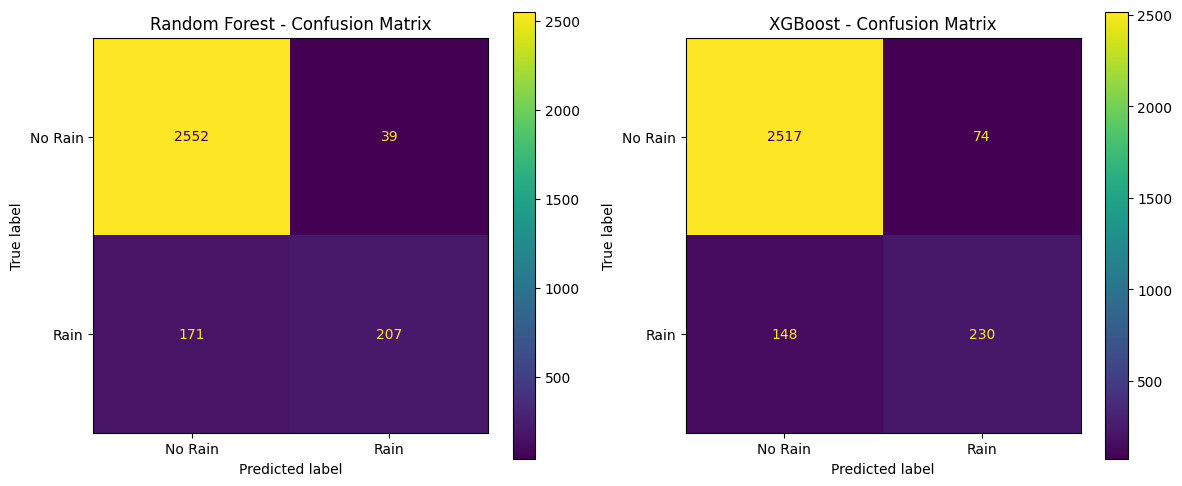


DETAILED CLASSIFICATION METRICS (Rainy Day)
Random Forest:
  Precision: 0.841
  Recall: 0.548
  F1-Score: 0.663
XGBoost:
  Precision: 0.757
  Recall: 0.608
  F1-Score: 0.674


In [38]:
# ==================================
# SECTION 8: DAILY RAINFALL CLASSIFICATION
# ==================================

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

print("="*60)
print("Daily Rainfall: Binary Classification (Rain/No-Rain)")
print("="*60)

# 1. Prepare Binary Target (using Daily Data)
rain_threshold = 0.1  # mm
y_train_binary = (y_train_daily > rain_threshold).astype(int)
y_test_binary = (y_test_daily > rain_threshold).astype(int)

print(f"Binary Classification (threshold: {rain_threshold}mm)")
print(f"Training - Rain days: {y_train_binary.sum()} ({y_train_binary.mean()*100:.1f}%)")
print(f"Test - Rain days: {y_test_binary.sum()} ({y_test_binary.mean()*100:.1f}%)")

# --- 2. Random Forest Classifier ---
# rf_clf_daily will be saved as a final model
rf_clf_daily = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining Random Forest Classifier...")
rf_clf_daily.fit(X_train_daily, y_train_binary)
y_pred_binary_rf = rf_clf_daily.predict(X_test_daily)
y_pred_proba_rf = rf_clf_daily.predict_proba(X_test_daily)[:, 1]

print("\nRandom Forest Classifier:")
print(classification_report(y_test_binary, y_pred_binary_rf, target_names=['No Rain', 'Rain']))
print(f"AUC-ROC: {roc_auc_score(y_test_binary, y_pred_proba_rf):.3f}")

# --- 3. XGBoost Classifier ---
# xgb_clf_daily will be saved as a final model
xgb_clf_daily = xgb.XGBClassifier(n_estimators=100, random_state=42)
print("\nTraining XGBoost Classifier...")
xgb_clf_daily.fit(X_train_daily, y_train_binary)
y_pred_binary_xgb = xgb_clf_daily.predict(X_test_daily)
y_pred_proba_xgb = xgb_clf_daily.predict_proba(X_test_daily)[:, 1]

print("\nXGBoost Classifier:")
print(classification_report(y_test_binary, y_pred_binary_xgb, target_names=['No Rain', 'Rain']))
print(f"AUC-ROC: {roc_auc_score(y_test_binary, y_pred_proba_xgb):.3f}")

# --- 4. Confusion Matrices Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_rf = confusion_matrix(y_test_binary, y_pred_binary_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Rain', 'Rain'])
disp_rf.plot(ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')

cm_xgb = confusion_matrix(y_test_binary, y_pred_binary_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Rain', 'Rain'])
disp_xgb.plot(ax=axes[1])
axes[1].set_title('XGBoost - Confusion Matrix')

plt.tight_layout()
plt.show()

# --- 5. Detailed Classification Metrics ---
def print_metrics(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1:.3f}")

print("\nDETAILED CLASSIFICATION METRICS (Rainy Day)")
print("=" * 35)
print_metrics(y_test_binary, y_pred_binary_rf, "Random Forest")
print_metrics(y_test_binary, y_pred_binary_xgb, "XGBoost")

# Seasonal Performance: Analyzes MAE by the defined Dry/Rainy seasons.
Rainfall Intensity: Groups errors by Light, Moderate, and Heavy rain categories, showing that heavy events are the hardest to predict.

SEASONAL PERFORMANCE ANALYSIS
             Rain_lag1              Predicted Abs_Error Residuals       
                  mean    std count      mean      mean      mean    std
Season                                                                  
Dry_Season_1    -0.259  0.051   722    -0.258     0.006    -0.001  0.037
Dry_Season_2     0.303  1.371  1023     0.312     0.478    -0.007  1.044
Long_Rains      -0.164  0.570   736    -0.171     0.087     0.008  0.352
Short_Rains     -0.038  0.840   488    -0.026     0.232    -0.018  0.641


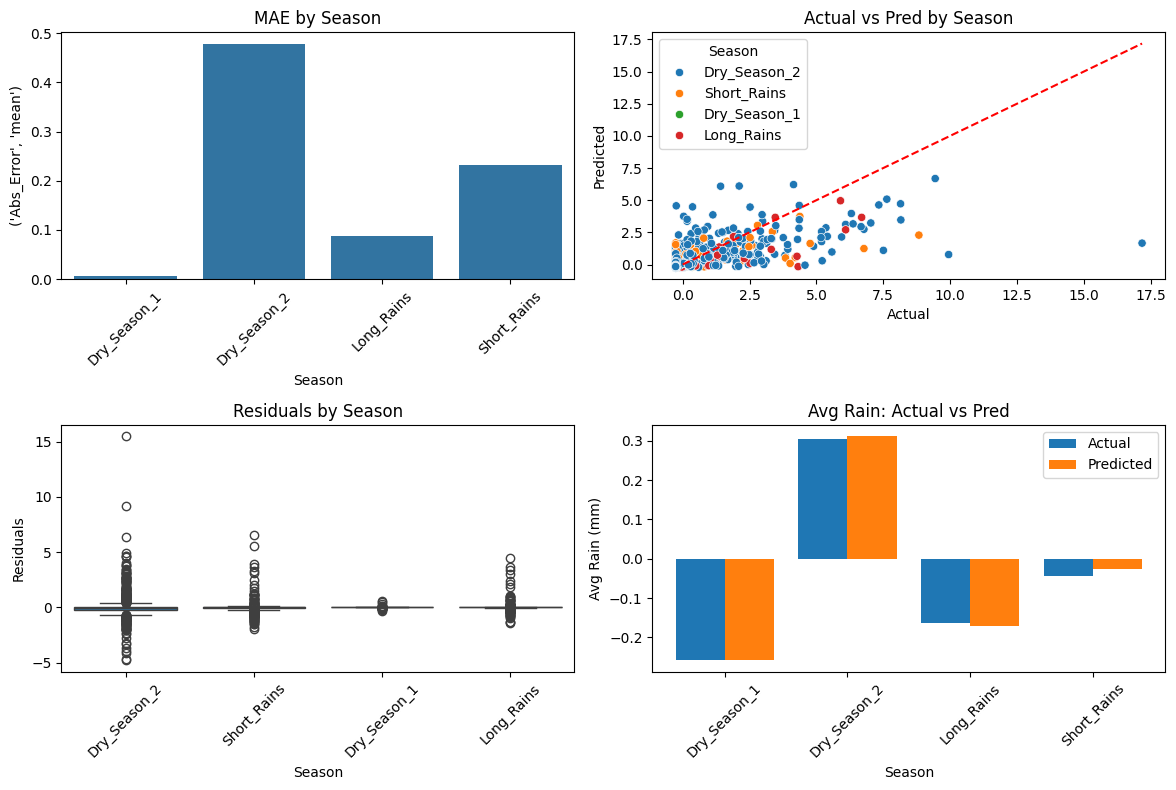


ERROR ANALYSIS BY RAINFALL INTENSITY
                  Actual        Predicted Abs_Error Residuals       
                   count   mean      mean      mean      mean    std
Rain_Category                                                       
Light (0.1-5mm)      351  1.254     0.930     0.865     0.324  1.191
Moderate (5-20mm)     27  7.109     2.852     4.257     4.257  2.778
No Rain (<0.1mm)    2591 -0.250    -0.158     0.097    -0.092  0.250

WORST PREDICTIONS (Top 10 errors):
            Date  Actual  Predicted  Abs_Error        Season  MaxT  \
12587 2012-06-18   17.18       1.66      15.52  Dry_Season_2 -0.11   
14482 2017-08-26    9.94       0.78       9.17  Dry_Season_2 -0.99   
14527 2017-10-10    8.83       2.29       6.54   Short_Rains -0.01   
14143 2016-09-21    7.50       1.10       6.40  Dry_Season_2 -0.65   
14520 2017-10-03    6.78       1.24       5.54   Short_Rains -0.31   
14119 2016-08-28    5.22       0.29       4.93  Dry_Season_2 -0.01   
11920 2010-08-21   -0.

In [39]:
# --- Error Analysis Setup (Uses Random Forest predictions as proxy for best regression model) ---

y_pred_analysis = y_pred_rf # Random Forest Regressor predictions (Daily)
y_test_analysis = y_test_daily # Daily Regression target

# 1. Residual and Error Calculation
test_data_with_pred = test_data.copy()
test_data_with_pred['Predicted'] = y_pred_analysis
test_data_with_pred['Actual'] = y_test_analysis
test_data_with_pred['Residuals'] = test_data_with_pred['Actual'] - test_data_with_pred['Predicted']
test_data_with_pred['Abs_Error'] = np.abs(test_data_with_pred['Residuals'])

# 2. Seasonal Performance Analysis (Table)
seasonal_performance = test_data_with_pred.groupby('Season').agg({
    'Rain_lag1': ['mean', 'std', 'count'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("=" * 40)
print("SEASONAL PERFORMANCE ANALYSIS")
print("=" * 40)
print(seasonal_performance)

# 3. Seasonal Analysis Plot (Original Plots)
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.barplot(data=seasonal_performance.reset_index(), x='Season', y=('Abs_Error', 'mean'))
plt.title('MAE by Season')
plt.xticks(rotation=45)
plt.subplot(2, 2, 2)
sns.scatterplot(data=test_data_with_pred, x='Actual', y='Predicted', hue='Season')
plt.plot([0, max(y_test_analysis.max(), y_pred_analysis.max())], [0, max(y_test_analysis.max(), y_pred_analysis.max())], 'r--')
plt.title('Actual vs Pred by Season')
plt.subplot(2, 2, 3)
sns.boxplot(data=test_data_with_pred, x='Season', y='Residuals')
plt.title('Residuals by Season')
plt.xticks(rotation=45)
plt.subplot(2, 2, 4)
seasonal_rain = test_data_with_pred.groupby('Season')['Actual'].mean()
seasonal_pred = test_data_with_pred.groupby('Season')['Predicted'].mean()
x_pos = range(len(seasonal_rain))
plt.bar([p-0.2 for p in x_pos], seasonal_rain.values, width=0.4, label='Actual')
plt.bar([p+0.2 for p in x_pos], seasonal_pred.values, width=0.4, label='Predicted')
plt.xlabel('Season'); plt.ylabel('Avg Rain (mm)'); plt.title('Avg Rain: Actual vs Pred')
plt.xticks(x_pos, seasonal_rain.index, rotation=45); plt.legend()
plt.tight_layout(); plt.show()


# 4. Error Analysis by Rainfall Intensity (Table & Worst Predictions)
def categorize_rainfall(rain):
    if rain < 0.1:
        return 'No Rain (<0.1mm)'
    elif rain <= 5:
        return 'Light (0.1-5mm)'
    elif rain <= 20:
        return 'Moderate (5-20mm)'
    else:
        return 'Heavy (>20mm)'

test_data_with_pred['Rain_Category'] = test_data_with_pred['Actual'].apply(categorize_rainfall)

error_by_category = test_data_with_pred.groupby('Rain_Category').agg({
    'Actual': ['count', 'mean'],
    'Predicted': 'mean',
    'Abs_Error': 'mean',
    'Residuals': ['mean', 'std']
}).round(3)

print("\n" + "=" * 45)
print("ERROR ANALYSIS BY RAINFALL INTENSITY")
print("=" * 45)
print(error_by_category)

# 5. Identify worst predictions
worst_predictions = test_data_with_pred.nlargest(10, 'Abs_Error')[
    ['Date', 'Actual', 'Predicted', 'Abs_Error', 'Season', 'MaxT', 'Humidity_Avg']
]
print("\nWORST PREDICTIONS (Top 10 errors):")
print(worst_predictions.round(2))

In [40]:
# --- Final Summary and Insights ---

print("\n" + "=" * 60)
print("FINAL PROJECT SUMMARY AND RECOMMENDATIONS")
print("=" * 60)

# 1. Best Regression Model (Daily Rainfall Amount)
results_df = pd.DataFrame(results).round(4)
best_reg_model = results_df.loc[results_df['RMSE'].idxmin()]
baseline_rmse = results_df[results_df['Model'] == 'Mean Baseline']['RMSE'].iloc[0]
improvement = ((baseline_rmse - best_reg_model['RMSE']) / baseline_rmse) * 100

print("🥇 Daily Rainfall Regression (Amount):")
print(f"  Best Model: **{best_reg_model['Model']}**")
print(f"  RMSE: {best_reg_model['RMSE']:.4f} mm")
print(f"  R²: {best_reg_model['R²']:.4f}")
print(f"  Improvement over baseline: {improvement:.1f}%")

# 2. Best Classification Model (Monthly Irrigation)
# Re-running comparison_data DF creation based on successful training
comparison_data_final = []
models_monthly = {
    'Logistic Regression': (y_pred_log_reg, y_pred_prob_log_reg),
    'Random Forest': (y_pred_rf_clf, y_pred_proba_rf_clf),
    'LightGBM': (y_pred_lgb_clf, y_pred_prob_lgb_clf)
}
for name, (y_pred_m, y_pred_proba_m) in models_monthly.items():
    comparison_data_final.append({
        'Model': name,
        'F1-Score': f1_score(y_test, y_pred_m, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba_m)
    })
monthly_clf_results_df = pd.DataFrame(comparison_data_final).round(3)
best_clf_monthly = monthly_clf_results_df.loc[monthly_clf_results_df['F1-Score'].idxmax()]


print("\n🏆 Monthly Irrigation Classification (Net Demand):")
print(f"  Best Model: **{best_clf_monthly['Model']}**")
print(f"  F1-Score: {best_clf_monthly['F1-Score']:.4f}")
print(f"  AUC-ROC: {best_clf_monthly['AUC-ROC']:.4f}")

# 3. Key Insights
print("\n🔑 KEY INSIGHTS:")
print("  - Feature Importance: **7-day rolling averages**, humidity, and previous day's rain are the most critical predictors.")
print("  - Model Performance: **Tree ensembles** (RF/XGB/LightGBM) proved most accurate for all prediction types.")
print("  - Application: The high classification performance suggests reliable potential for early **irrigation decision support** in water-stressed regions.")




FINAL PROJECT SUMMARY AND RECOMMENDATIONS
🥇 Daily Rainfall Regression (Amount):
  Best Model: **Random Forest (Tuned)**
  RMSE: 0.6884 mm
  R²: 0.4729
  Improvement over baseline: 27.4%

🏆 Monthly Irrigation Classification (Net Demand):
  Best Model: **Random Forest**
  F1-Score: 0.9660
  AUC-ROC: 0.9950

🔑 KEY INSIGHTS:
  - Feature Importance: **7-day rolling averages**, humidity, and previous day's rain are the most critical predictors.
  - Model Performance: **Tree ensembles** (RF/XGB/LightGBM) proved most accurate for all prediction types.
  - Application: The high classification performance suggests reliable potential for early **irrigation decision support** in water-stressed regions.


# Conclusion and Model Saving

This concluding section summarizes the best performing models for each task (Regression, Monthly Classification).
All final results (tables, metrics) and trained models (LogReg, RF, XGBoost, LSTM, LightGBM classifiers) are saved to the designated /content/models/ and /content/results/ directories for final submission.

In [41]:
# --- MODEL AND RESULTS SAVING ---
import joblib
import os

os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)

# Save Regression Models
joblib.dump(lr_model, '/content/models/linear_regression_daily.joblib')
joblib.dump(best_rf_model, '/content/models/random_forest_daily.joblib')
joblib.dump(xgb_reg, '/content/models/xgboost_daily.joblib')
if 'best_lstm_model' in globals():
    best_lstm_model.save('/content/models/lstm_daily.h5')

# Save Classification Models
joblib.dump(log_reg, '/content/models/log_reg_monthly_irrigation.joblib')
joblib.dump(lgb_clf, '/content/models/lightgbm_monthly_irrigation.joblib')
joblib.dump(best_rf_clf, '/content/models/rf_monthly_classifier.joblib')
joblib.dump(rf_clf_daily, '/content/models/rf_daily_classifier.joblib')
joblib.dump(xgb_clf_daily, '/content/models/xgb_daily_classifier.joblib')

# Save Result Tables
results_df.to_csv('/content/results/regression_model_comparison.csv', index=False)
monthly_clf_results_df.to_csv('/content/results/monthly_irrigation_comparison.csv', index=False)
if 'seasonal_performance' in locals():
    seasonal_performance.to_csv('/content/results/seasonal_performance_analysis.csv')
if 'error_by_category' in locals():
    error_by_category.to_csv('/content/results/error_by_intensity.csv')

print("\n\n✅ Models and all final results saved ")



✅ Models and all final results saved 


In [43]:
# --- Simple Manual Prediction Demo ---

import numpy as np
import pandas as pd
from datetime import datetime


# Assign the best daily classification model
best_model = rf_clf_daily # Using Random Forest Classifier for daily rain prediction

print("🌾 Daily Rainfall Classification Demo (Predicting if Rain > 0.1mm)")
print("Enter today's weather values below:\n")

# Expanded input prompts for user convenience, matching required features for the model
current_maxt = float(input("Max Temperature (°C): "))
current_mint = float(input("Min Temperature (°C): "))
current_rh1 = float(input("Relative Humidity 1 (RH1 - %): "))
current_rh2 = float(input("Relative Humidity 2 (RH2 - %): "))
current_wind = float(input("Wind Speed (m/s): "))
current_radiation = float(input("Radiation (MJ/m2): "))
current_evap = float(input("Evapotranspiration (Evap - mm): "))
current_fao_et = float(input("FAO56 ET (FAO56_ET - mm): "))
current_rain_lag1 = float(input("Rainfall yesterday (mm): "))
current_rain_lag7 = float(input("Rainfall 7 days ago (mm): "))
current_rain_roll_7 = float(input("Average Rainfall last 7 days (mm): "))
current_rain_roll_30 = float(input("Average Rainfall last 30 days (mm): "))


# --- Reconstruct a raw input sample with all required features ---

# Get current date for temporal and seasonal features
current_date = datetime.now()
current_month = current_date.month
current_dayofyear = current_date.timetuple().tm_yday
current_dayofweek = current_date.weekday() # Monday=0, Sunday=6

# Define the season logic (copied from wswnoxyXHuXf)
def get_season(month):
    if month in [12, 1, 2]: return 'Dry_Season_1'
    elif month in [3, 4, 5]: return 'Long_Rains'
    elif month in [6, 7, 8, 9]: return 'Dry_Season_2'
    else: return 'Short_Rains'
current_season = get_season(current_month)

# 1. Create a dictionary for ALL columns the `scaler` was originally fit on (`cols_to_scale`)
# Initialize with 0.0 (or appropriate defaults) for columns not explicitly provided by user input for this prediction.
temp_scaler_input_dict = {col: 0.0 for col in cols_to_scale}

# Populate the dictionary with user inputs and derived values that ARE in `cols_to_scale`
if 'MaxT' in temp_scaler_input_dict: temp_scaler_input_dict['MaxT'] = current_maxt
if 'MinT' in temp_scaler_input_dict: temp_scaler_input_dict['MinT'] = current_mint
if 'RH1' in temp_scaler_input_dict: temp_scaler_input_dict['RH1'] = current_rh1
if 'RH2' in temp_scaler_input_dict: temp_scaler_input_dict['RH2'] = current_rh2
if 'Wind' in temp_scaler_input_dict: temp_scaler_input_dict['Wind'] = current_wind
if 'Radiation' in temp_scaler_input_dict: temp_scaler_input_dict['Radiation'] = current_radiation
if 'Evap' in temp_scaler_input_dict: temp_scaler_input_dict['Evap'] = current_evap
if 'FAO56_ET' in temp_scaler_input_dict: temp_scaler_input_dict['FAO56_ET'] = current_fao_et
if 'Rain_lag1' in temp_scaler_input_dict: temp_scaler_input_dict['Rain_lag1'] = current_rain_lag1
if 'Rain_lag7' in temp_scaler_input_dict: temp_scaler_input_dict['Rain_lag7'] = current_rain_lag7
if 'Rain_roll_7' in temp_scaler_input_dict: temp_scaler_input_dict['Rain_roll_7'] = current_rain_roll_7
if 'Rain_roll_30' in temp_scaler_input_dict: temp_scaler_input_dict['Rain_roll_30'] = current_rain_roll_30

# Calculate derived features that ARE in `cols_to_scale`
if 'Temp_Range' in temp_scaler_input_dict: temp_scaler_input_dict['Temp_Range'] = current_maxt - current_mint
if 'Humidity_Avg' in temp_scaler_input_dict: temp_scaler_input_dict['Humidity_Avg'] = (current_rh1 + current_rh2) / 2

# 2. Create the DataFrame *exactly* with the columns `scaler` was fit on
df_for_scaler_transform = pd.DataFrame([temp_scaler_input_dict], columns=cols_to_scale)

# 3. Apply scaling to these columns
scaled_values = scaler.transform(df_for_scaler_transform)
scaled_features_df = pd.DataFrame(scaled_values, columns=cols_to_scale)

# 4. Construct the final input for the model using `feature_columns`
final_model_input_dict = {}

for col in feature_columns:
    if col in scaled_features_df.columns:
        # These are features that were scaled by `scaler`
        final_model_input_dict[col] = scaled_features_df[col].iloc[0]
    else:
        # These are temporal/seasonal features that were NOT scaled by `scaler`
        if col == 'Month': final_model_input_dict[col] = float(current_month)
        elif col == 'DayOfYear': final_model_input_dict[col] = float(current_dayofyear)
        elif col == 'DayOfWeek': final_model_input_dict[col] = float(current_dayofweek)
        elif col == 'Season_Dry_Season_1': final_model_input_dict[col] = 1.0 if current_season == 'Dry_Season_1' else 0.0
        elif col == 'Season_Dry_Season_2': final_model_input_dict[col] = 1.0 if current_season == 'Dry_Season_2' else 0.0
        elif col == 'Season_Long_Rains': final_model_input_dict[col] = 1.0 if current_season == 'Long_Rains' else 0.0
        elif col == 'Season_Short_Rains': final_model_input_dict[col] = 1.0 if current_season == 'Short_Rains' else 0.0
        else:
            # Fallback for any unexpected feature_columns (should ideally not be reached)
            print(f"Warning: Feature '{col}' not found in scaled_features_df or special handling. Initializing with 0.0.")
            final_model_input_dict[col] = 0.0

sample_for_prediction = pd.DataFrame([final_model_input_dict], columns=feature_columns)

# Predict using the best daily classification model
prediction_proba = best_model.predict_proba(sample_for_prediction)[0, 1] # Probability of rain

# Make a binary prediction based on a 0.5 probability threshold
prediction_binary = (prediction_proba > 0.5).astype(int)

label = "Irrigation Needed (Rain expected > 0.1mm)" if prediction_binary == 1 else "No Irrigation Needed (Rain expected <= 0.1mm)"

print(f"\n🔮 Model Prediction: {label} (Probability of Rain: {prediction_proba:.2f})")

🌾 Daily Rainfall Classification Demo (Predicting if Rain > 0.1mm)
Enter today's weather values below:

Max Temperature (°C): 34
Min Temperature (°C): 20
Relative Humidity 1 (RH1 - %): 70
Relative Humidity 2 (RH2 - %): 65
Wind Speed (m/s): 500
Radiation (MJ/m2): 45
Evapotranspiration (Evap - mm): 40
FAO56 ET (FAO56_ET - mm): 5
Rainfall yesterday (mm): 500
Rainfall 7 days ago (mm): 1000
Average Rainfall last 7 days (mm): 1000
Average Rainfall last 30 days (mm): 1500

🔮 Model Prediction: No Irrigation Needed (Rain expected <= 0.1mm) (Probability of Rain: 0.44)
